In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("boys_hostel_mains.csv", na_values=["NA"])

df["date"] = pd.to_datetime(df["timestamp"], unit="s")

df = df.sort_values("timestamp")
df = df.drop_duplicates(subset=["timestamp"])

# df["current_missing"] = df["current"].isna().astype(int)

# # Fill missing current values using P = V * I * PF
# df["current"] = df["current"].fillna(
#     df["power"] / (df["voltage"] * df["power_factor"])
# )

# Remove physically impossible values
df = df[df["power"] >= 0]
df = df[df["voltage"] > 0]
df = df[df["frequency"] > 0]
df = df[df["power_factor"] > 0]

print("\nMissing values:")
print(df.isna().sum())

print("\nDate range:")
print(df["date"].min())
print(df["date"].max())

print("\nTotal rows:", len(df))

df.to_csv("boys_hostel_mains_cleaned.csv", index=False)



Missing values:
timestamp            0
power                0
current         206398
voltage              0
frequency            0
power_factor         0
date                 0
dtype: int64

Date range:
2013-08-09 18:30:00
2017-12-31 18:29:00

Total rows: 937464


In [2]:
import pandas as pd

df = pd.read_csv("boys_hostel_mains_cleaned.csv")

print(df.head())

      timestamp        power  current    voltage  frequency  power_factor  \
0  1.376073e+09  28298.05859      NaN  243.54842   50.33528       0.96101   
1  1.376073e+09  28327.11426      NaN  243.72989   50.36023       0.96289   
2  1.376073e+09  28343.01562      NaN  243.94641   50.41634       0.96056   
3  1.376073e+09  28447.11719      NaN  244.36275   50.45324       0.96228   
4  1.376073e+09  28393.62207      NaN  244.48650   50.43779       0.96166   

                  date  
0  2013-08-09 18:30:00  
1  2013-08-09 18:31:00  
2  2013-08-09 18:32:00  
3  2013-08-09 18:33:00  
4  2013-08-09 18:34:00  


In [4]:
!pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.2 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 22.1 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 22.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------------------------------- -------- 5.5/7.1 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 23.0 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install pyod

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 17.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.2 MB 16.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 16.2 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 15.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---- ----------------------------------- 3.7/36.5 MB 16.8 MB/s eta 0:00:02
   -------- ------------------------------- 7.3/36.5 MB 17.4 MB/s eta 0:00:02
   ------------ --------------------------- 11.3/36.5 MB 17.6 MB/s eta 0:00:02
   ------------------ --------------------- 16.8/36.5 MB 19.6 MB/


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


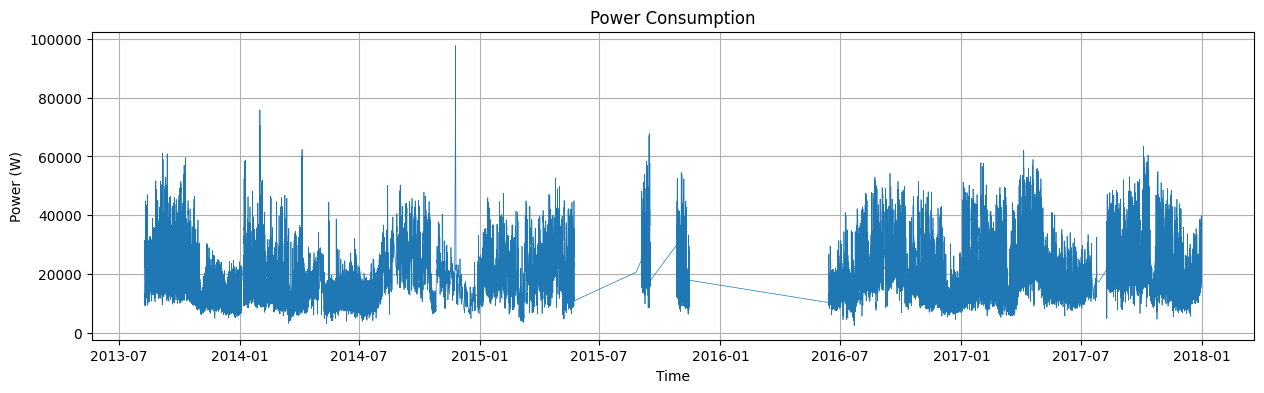

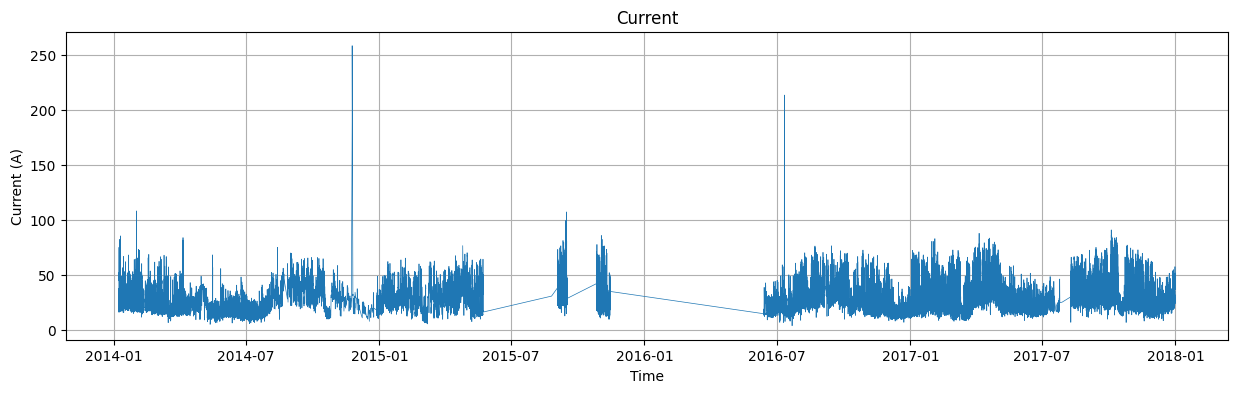

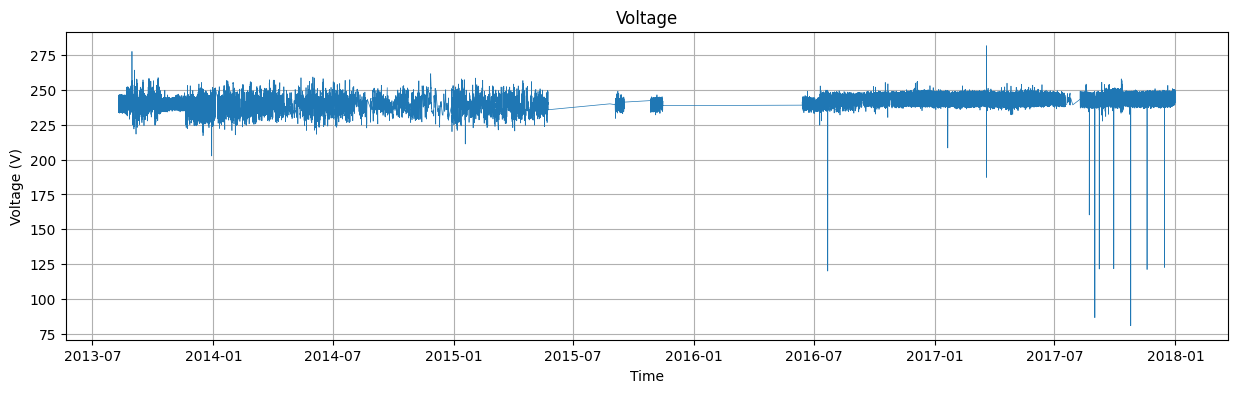

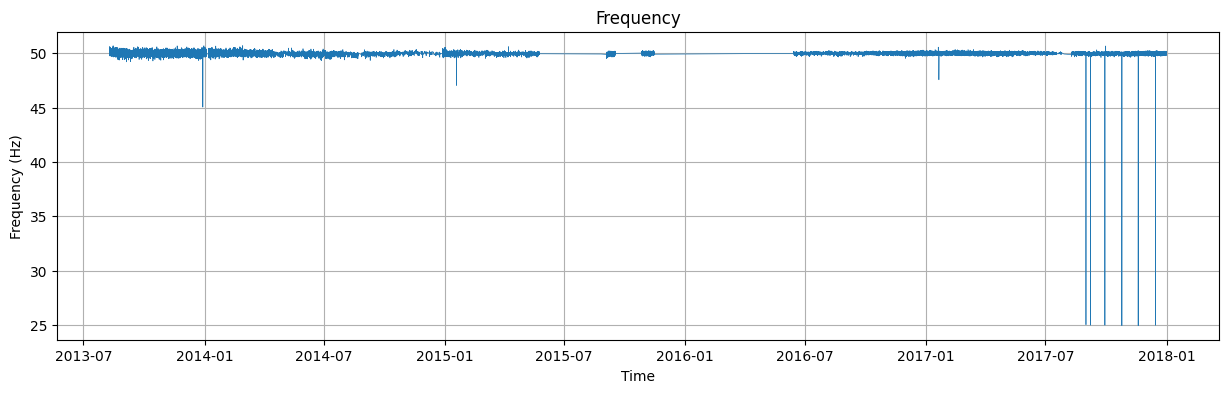

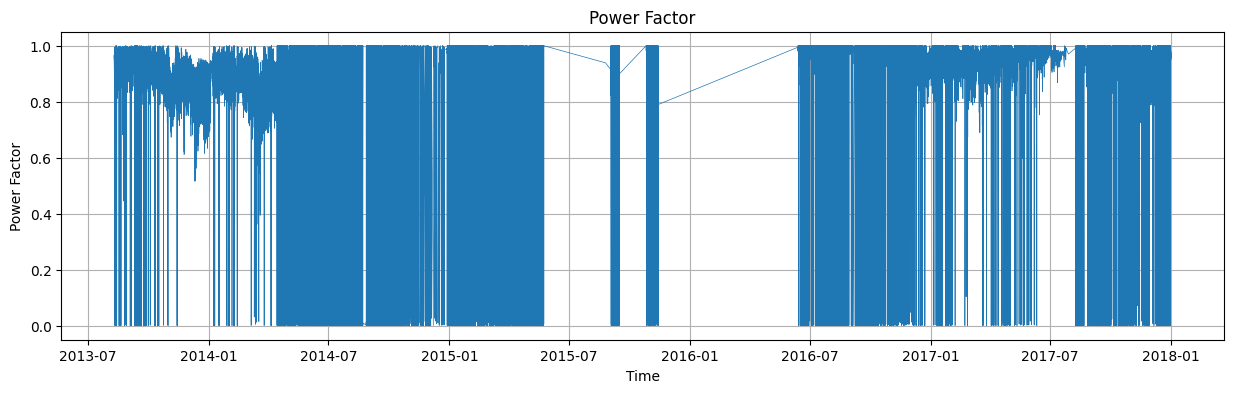

,timestamp,power,current,voltage,frequency,power_factor,date
count,9.374640e+05,937464.000000,731066.000000,937464.000000,937464.000000,937464.000000,937464
mean,1.446552e+09,19159.691665,28.207465,241.671159,49.996133,0.932870,2015-11-03 11:57:29.365672
min,1.376073e+09,2419.644000,3.524950,80.732000,24.938600,0.000010,2013-08-09 18:30:00
25%,1.390743e+09,12755.473525,19.228320,239.065867,49.937410,0.918800,2014-01-26 13:30:45
50%,1.471685e+09,16924.886405,25.146150,242.012300,49.994940,0.966510,2016-08-20 09:30:30
75%,1.492490e+09,23702.374787,34.156847,244.997100,50.050440,0.985970,2017-04-18 04:40:15
max,1.514745e+09,97663.860000,258.363000,281.761800,50.696990,1.000000,2017-12-31 18:29:00
std,5.176674e+07,8862.693077,12.459179,4.830900,0.127692,0.124719,NaN



Missing values:
timestamp            0
power                0
current         206398
voltage              0
frequency            0
power_factor         0
date                 0
dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("boys_hostel_mains_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["power"], linewidth=0.5)
plt.title("Power Consumption")
plt.xlabel("Time")
plt.ylabel("Power (W)")
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["current"], linewidth=0.5)
plt.title("Current")
plt.xlabel("Time")
plt.ylabel("Current (A)")
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["voltage"], linewidth=0.5)
plt.title("Voltage")
plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["frequency"], linewidth=0.5)
plt.title("Frequency")
plt.xlabel("Time")
plt.ylabel("Frequency (Hz)")
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["power_factor"], linewidth=0.5)
plt.title("Power Factor")
plt.xlabel("Time")
plt.ylabel("Power Factor")
plt.grid(True)
plt.show()

display(df.describe())

print("\nMissing values:")
print(df.isna().sum())

In [4]:
#PYOD baseline runs 
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.pca import PCA
from pyod.models.ocsvm import OCSVM
from pyod.models.abod import ABOD
from pyod.models.mcd import MCD

X = df[["power"]].values

model = IForest(
    contamination=0.01,
    random_state=42
)

model.fit(X)

df["anomaly"] = model.labels_
df["score"] = model.decision_scores_

print(df["anomaly"].value_counts())

anomaly
0    928107
1      9357
Name: count, dtype: int64


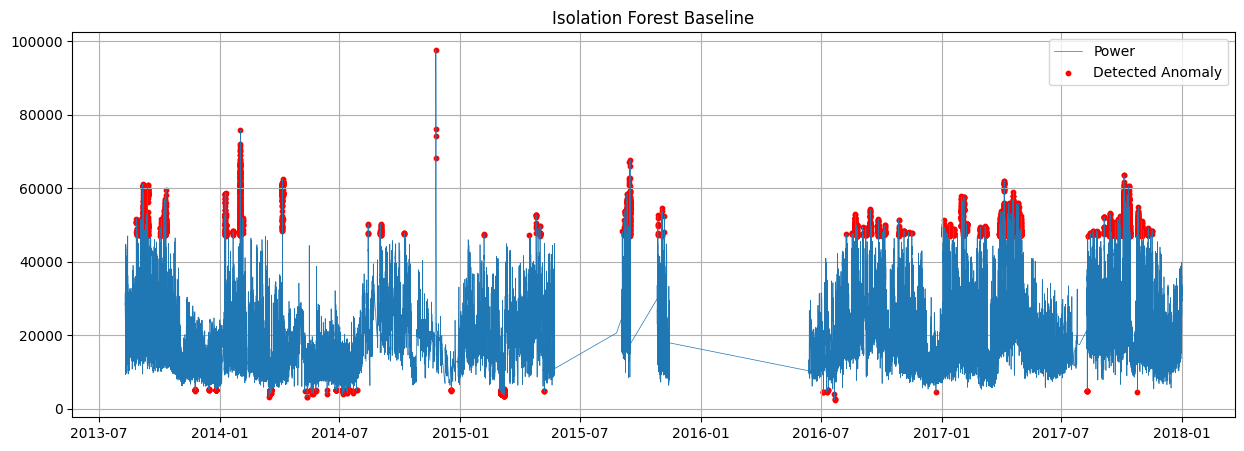

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["date"],
    df["power"],
    linewidth=0.5,
    label="Power"
)

anoms = df[df["anomaly"] == 1]

plt.scatter(
    anoms["date"],
    anoms["power"],
    color="red",
    s=10,
    label="Detected Anomaly"
)

plt.title("Isolation Forest Baseline")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
models = {
    "IForest": IForest(contamination=0.01, random_state=42),
    "ECOD": ECOD(contamination=0.01),
    "COPOD": COPOD(contamination=0.01),
    "HBOS": HBOS(contamination=0.01),
    "LOF": LOF(contamination=0.01),
    "KNN": KNN(contamination=0.01)
}

X = df[["power"]].values

for name, model in models.items():

    model.fit(X)

    preds = model.labels_
    scores = model.decision_scores_

    print(f"{name}: {preds.sum()} anomalies detected")

    anoms = df[preds == 1]

    plt.figure(figsize=(15, 5))

    plt.plot(
        df["date"],
        df["power"],
        linewidth=0.5,
        label="Power"
    )

    plt.scatter(
        anoms["date"],
        anoms["power"],
        color="red",
        s=10,
        label="Detected Anomaly"
    )

    plt.title(f"{name} Baseline")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
models = {
    "IForest": IForest(contamination=0.01, random_state=42),
    "ECOD": ECOD(contamination=0.01),
    "COPOD": COPOD(contamination=0.01),
    "HBOS": HBOS(contamination=0.01),
    "LOF": LOF(contamination=0.01),
    "KNN": KNN(contamination=0.01)
}

cols = ["power", "current", "voltage", "frequency", "power_factor"]

for col in cols:

    # Use only non-NaN values for the model
    temp_df = df.dropna(subset=[col]).copy()
    X = temp_df[[col]].values

    for name, model in models.items():

        model.fit(X)

        preds = model.labels_
        scores = model.decision_scores_

        print(f"{col} | {name}: {preds.sum()} anomalies detected")

        # Anomalies detected by the model
        anoms = temp_df[preds == 1]

        # Plot full dataset (including NaN gaps)
        plt.figure(figsize=(15, 5))

        plt.plot(
            df["date"],
            df[col],
            linewidth=0.5,
            label=col
        )

        plt.scatter(
            anoms["date"],
            anoms[col],
            color="red",
            s=10,
            label="Detected Anomaly"
        )

        plt.title(f"{name} Baseline on {col}")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.legend()
        plt.grid(True)
        plt.show()


Injected 9374 power spike anomalies.


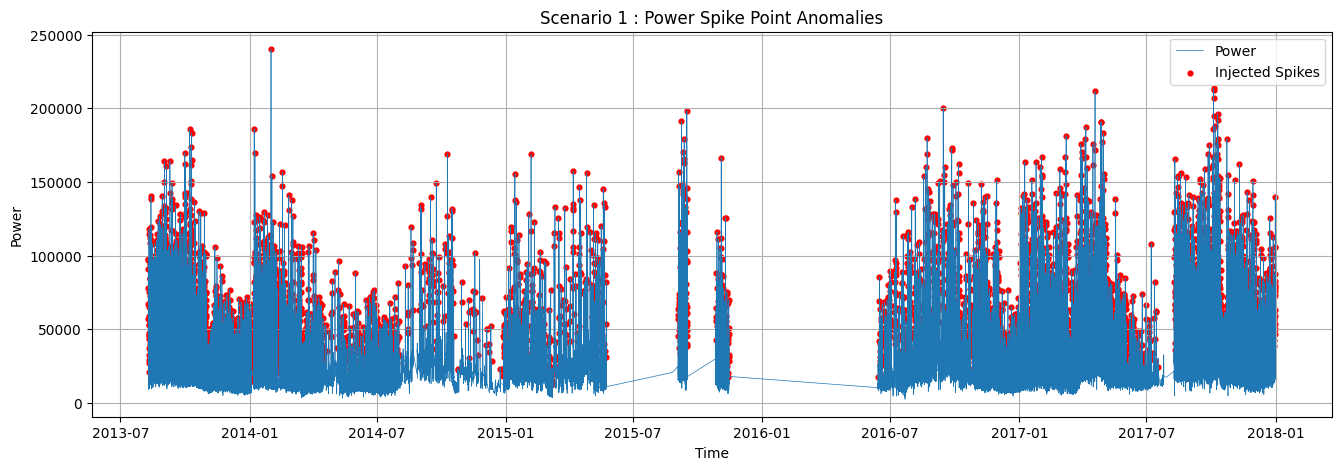


Running IForest
Detected Anomalies : 9162
Precision          : 0.5385
Recall             : 0.5263
F1 Score           : 0.5324
ROC AUC            : 0.9291
PR AUC             : 0.5494


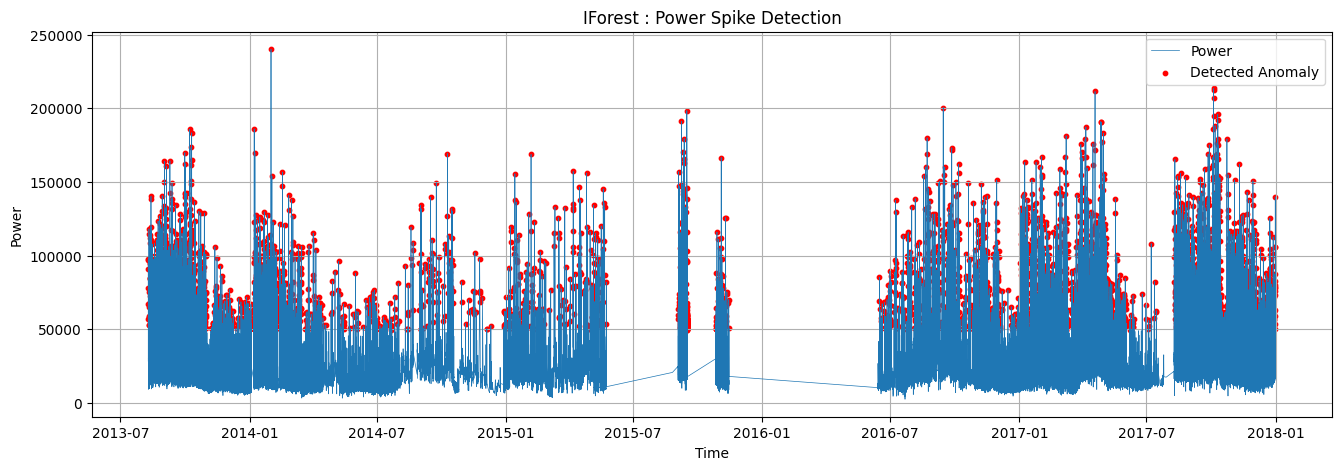


Running ECOD
Detected Anomalies : 9374
Precision          : 0.4261
Recall             : 0.4261
F1 Score           : 0.4261
ROC AUC            : 0.8986
PR AUC             : 0.2832


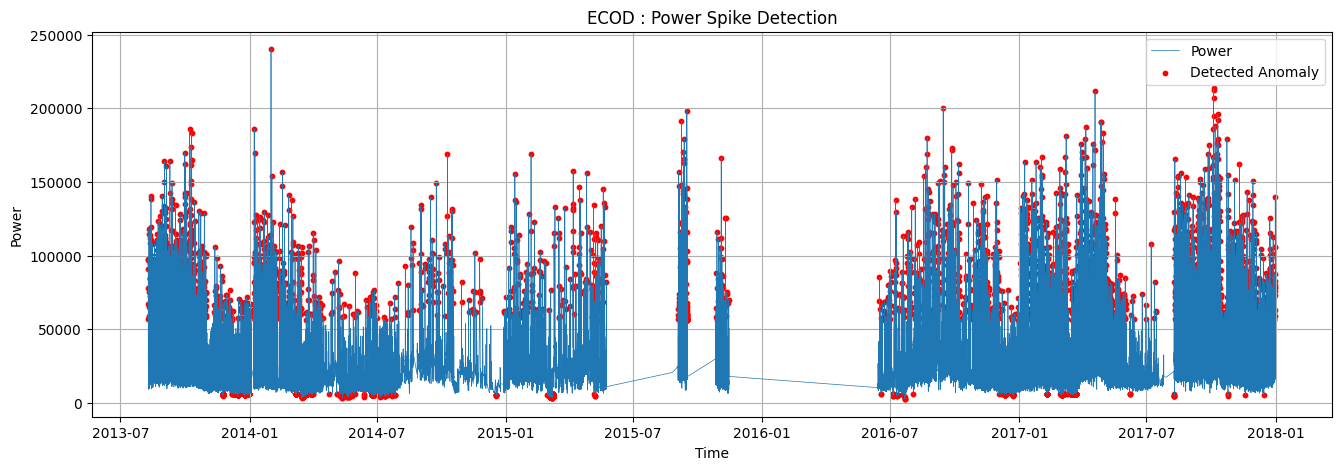


Running COPOD
Detected Anomalies : 9375
Precision          : 0.5268
Recall             : 0.5269
F1 Score           : 0.5269
ROC AUC            : 0.9368
PR AUC             : 0.5617


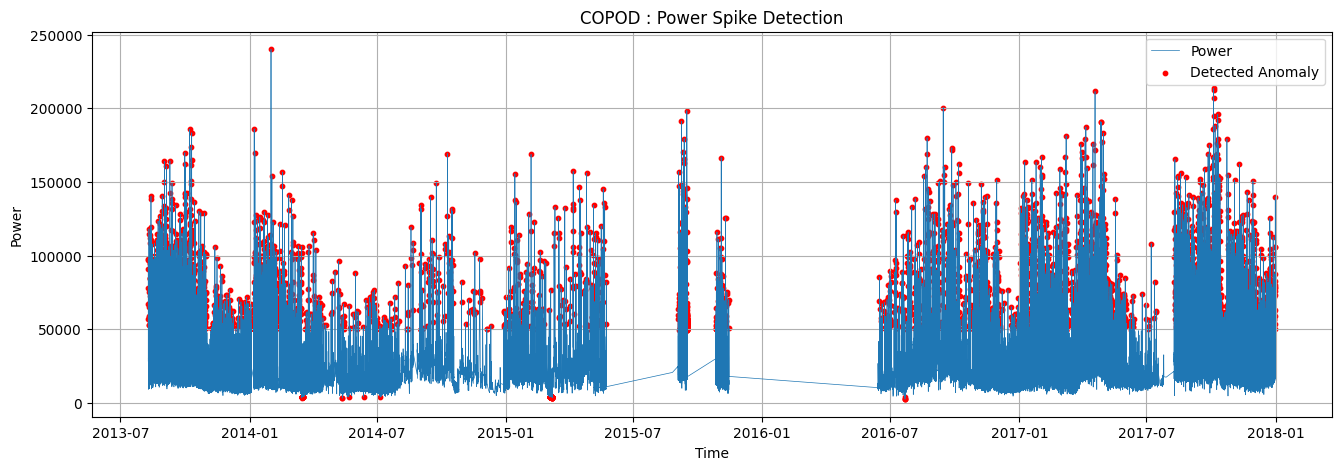


Running HBOS
Detected Anomalies : 8746
Precision          : 0.5567
Recall             : 0.5194
F1 Score           : 0.5374
ROC AUC            : 0.9111
PR AUC             : 0.4114


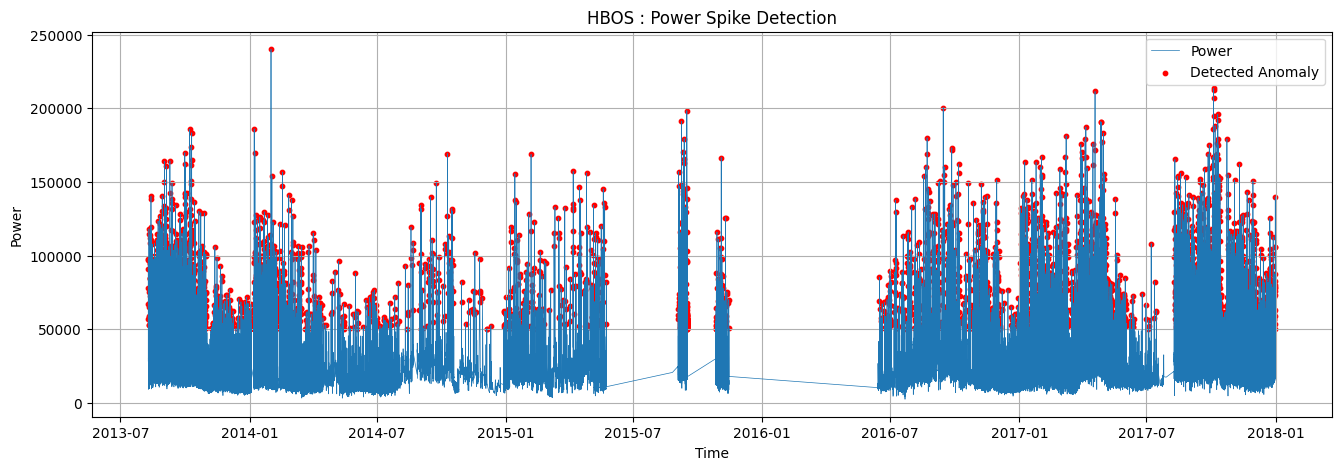


Running LOF
Detected Anomalies : 9375
Precision          : 0.0130
Recall             : 0.0130
F1 Score           : 0.0130
ROC AUC            : 0.5018
PR AUC             : 0.0105


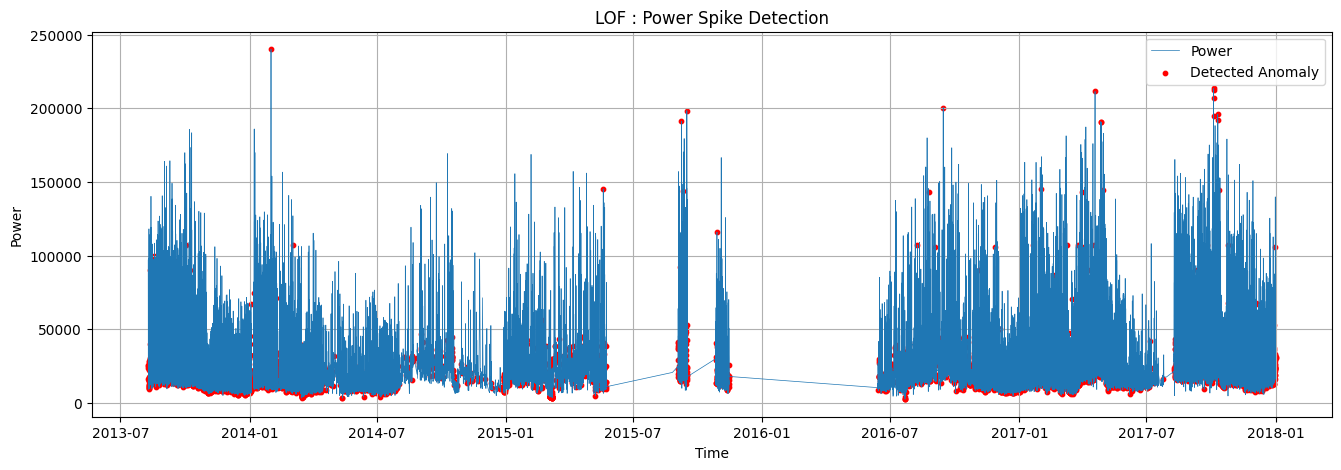


Running KNN
Detected Anomalies : 9375
Precision          : 0.5126
Recall             : 0.5127
F1 Score           : 0.5127
ROC AUC            : 0.9266
PR AUC             : 0.5381


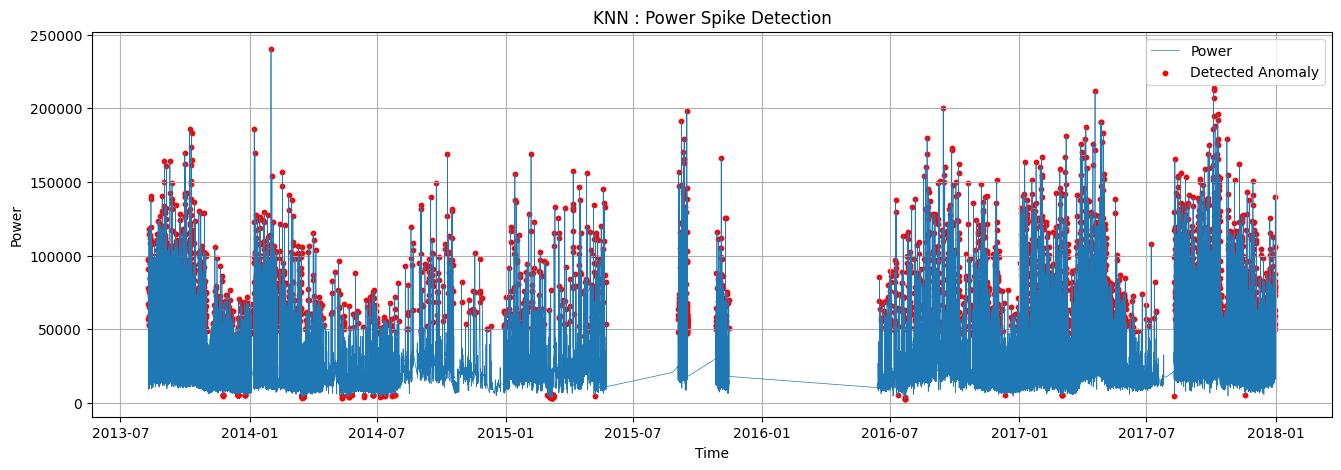


Running PCA
Detected Anomalies : 9375
Precision          : 0.4666
Recall             : 0.4666
F1 Score           : 0.4666
ROC AUC            : 0.6826
PR AUC             : 0.4640


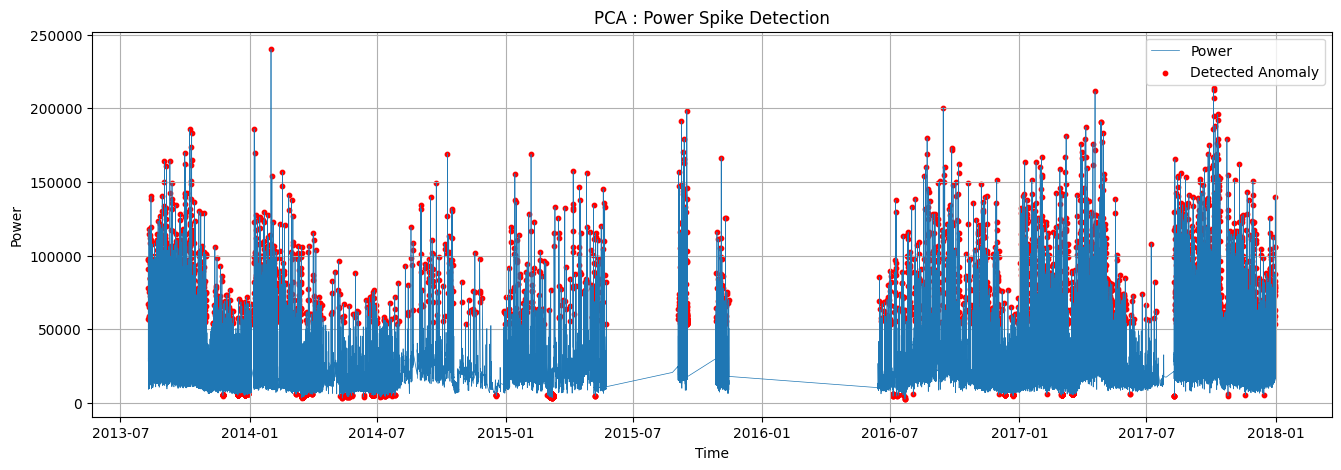


Running MCD
Detected Anomalies : 9375
Precision          : 0.5283
Recall             : 0.5284
F1 Score           : 0.5283
ROC AUC            : 0.9377
PR AUC             : 0.5656


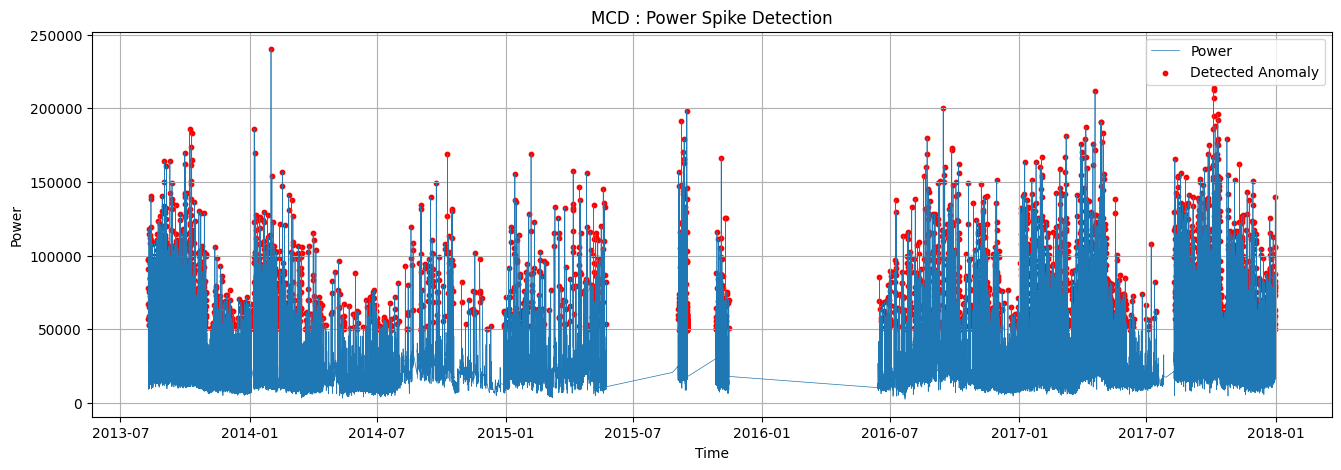


Running LODA
Detected Anomalies : 8746
Precision          : 0.5567
Recall             : 0.5194
F1 Score           : 0.5374
ROC AUC            : 0.9111
PR AUC             : 0.4114


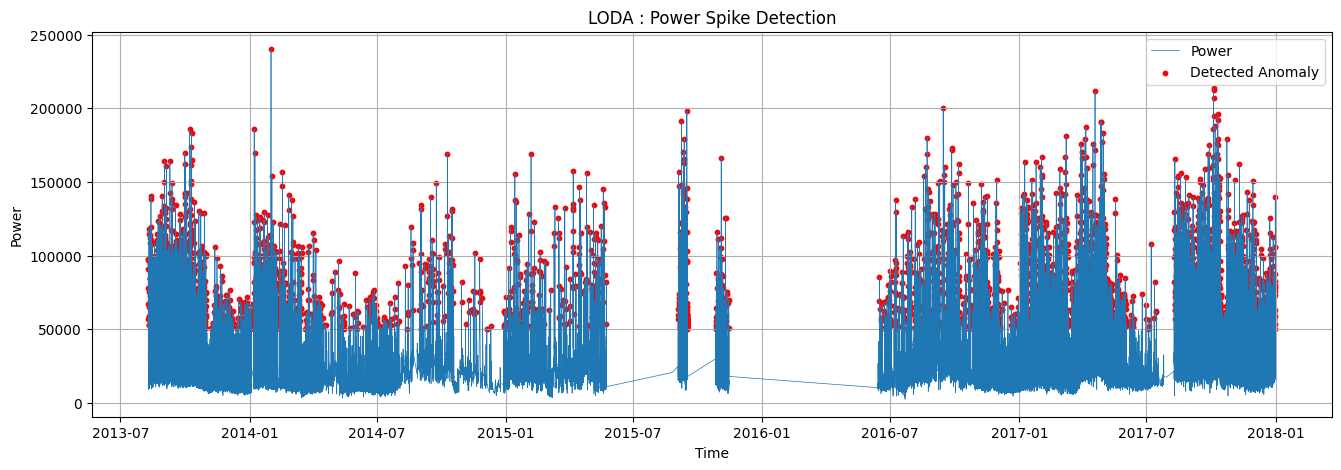


Running INNE
Detected Anomalies : 9256
Precision          : 0.5248
Recall             : 0.5182
F1 Score           : 0.5215
ROC AUC            : 0.9283
PR AUC             : 0.5471


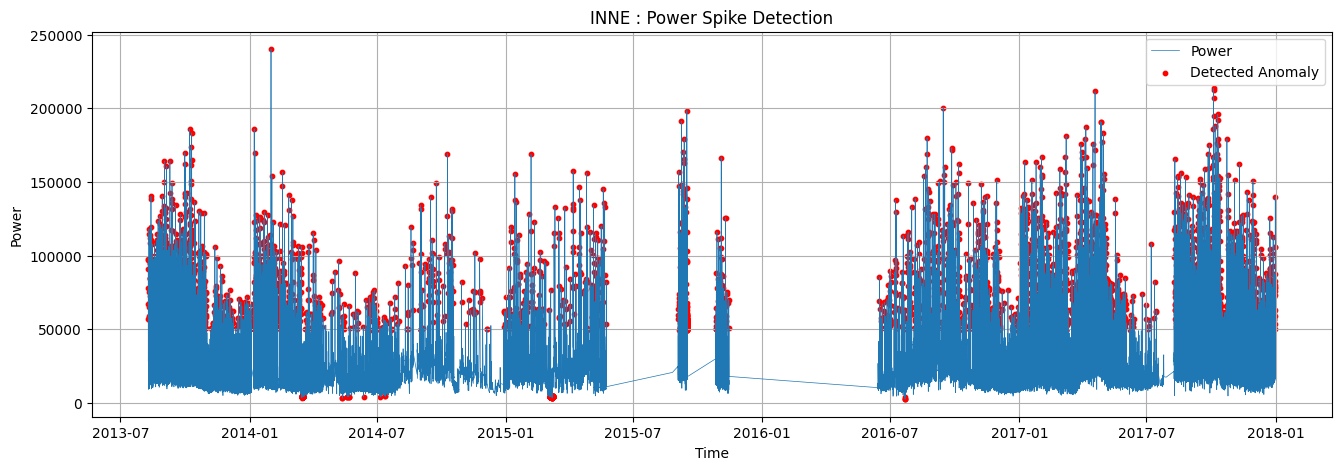



BENCHMARK SUMMARY


,Scenario,Model,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,FN,TN
8,Power Spike,LODA,0.556712,0.519415,0.537417,0.911087,0.411385,4869,3877,4505,924213
3,Power Spike,HBOS,0.556712,0.519415,0.537417,0.911087,0.411385,4869,3877,4505,924213
0,Power Spike,IForest,0.538529,0.526349,0.532369,0.929073,0.549442,4934,4228,4440,923862
7,Power Spike,MCD,0.528320,0.528376,0.528348,0.937729,0.565612,4953,4422,4421,923668
2,Power Spike,COPOD,0.526827,0.526883,0.526855,0.936783,0.561713,4939,4436,4435,923654
9,Power Spike,INNE,0.524849,0.518242,0.521524,0.928287,0.547061,4858,4398,4516,923692
5,Power Spike,KNN,0.512640,0.512695,0.512667,0.926568,0.538115,4806,4569,4568,923521
6,Power Spike,PCA,0.466560,0.466610,0.466585,0.682614,0.463964,4374,5001,5000,923089
1,Power Spike,ECOD,0.426072,0.426072,0.426072,0.898594,0.283170,3994,5380,5380,922710
4,Power Spike,LOF,0.013013,0.013015,0.013014,0.501769,0.010486,122,9253,9252,918837


In [3]:
# ============================================
# SCENARIO 1 : POWER SPIKE (POINT ANOMALY)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# PyOD Models
# -------------------------------
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.pca import PCA
from pyod.models.mcd import MCD
from pyod.models.loda import LODA
from pyod.models.inne import INNE

# -------------------------------
# Evaluation Metrics
# -------------------------------
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# -------------------------------
# Load cleaned dataset
# -------------------------------
df = pd.read_csv("boys_hostel_mains_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

# ============================================
# Inject Power Spike Anomalies
# ============================================

labels = np.zeros(len(df), dtype=int)

np.random.seed(42)

# Inject into 1% of the dataset
n_anomalies = int(0.01 * len(df))

anomaly_indices = np.random.choice(
    df.index,
    size=n_anomalies,
    replace=False
)

# Create spikes between 2x and 4x
spike_multiplier = np.random.uniform(
    low=2.0,
    high=4.0,
    size=n_anomalies
)

df.loc[anomaly_indices, "power"] = (
    df.loc[anomaly_indices, "power"].values
    * spike_multiplier
)

# Ground truth labels
labels[anomaly_indices] = 1
df["label"] = labels

print(f"\nInjected {labels.sum()} power spike anomalies.")

# ============================================
# Visualize Injected Scenario
# ============================================

plt.figure(figsize=(16, 5))

plt.plot(
    df["date"],
    df["power"],
    linewidth=0.5,
    label="Power"
)

plt.scatter(
    df.loc[anomaly_indices, "date"],
    df.loc[anomaly_indices, "power"],
    color="red",
    s=12,
    label="Injected Spikes"
)

plt.title("Scenario 1 : Power Spike Point Anomalies")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# PyOD Benchmark Models
# ============================================

models = {
    "IForest": IForest(contamination=0.01, random_state=42),
    "ECOD": ECOD(contamination=0.01),
    "COPOD": COPOD(contamination=0.01),
    "HBOS": HBOS(contamination=0.01),
    "LOF": LOF(contamination=0.01),
    "KNN": KNN(contamination=0.01),
    "PCA": PCA(contamination=0.01),
    "MCD": MCD(contamination=0.01, random_state=42),
    "LODA": LODA(contamination=0.01),
    "INNE": INNE(contamination=0.01)
}

# Input feature
X = df[["power"]].values

# Store benchmark results
results = []

# ============================================
# Run All Models
# ============================================

for name, model in models.items():

    print("\n" + "=" * 50)
    print(f"Running {name}")
    print("=" * 50)

    # Train
    model.fit(X)

    # Predictions
    predictions = model.labels_
    scores = model.decision_scores_

    # Evaluation
    y_true = df["label"].values
    y_pred = predictions
    y_score = scores

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    # Store results
    results.append({
        "Scenario": "Power Spike",
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

    # Print summary
    print(f"Detected Anomalies : {y_pred.sum()}")
    print(f"Precision          : {precision:.4f}")
    print(f"Recall             : {recall:.4f}")
    print(f"F1 Score           : {f1:.4f}")
    print(f"ROC AUC            : {roc_auc:.4f}")
    print(f"PR AUC             : {pr_auc:.4f}")

    # Visualize detections
    detected = df[y_pred == 1]

    plt.figure(figsize=(16, 5))

    plt.plot(
        df["date"],
        df["power"],
        linewidth=0.5,
        label="Power"
    )

    plt.scatter(
        detected["date"],
        detected["power"],
        color="red",
        s=10,
        label="Detected Anomaly"
    )

    plt.title(f"{name} : Power Spike Detection")
    plt.xlabel("Time")
    plt.ylabel("Power")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Save predictions into dataframe
    df[f"{name}_pred"] = y_pred
    df[f"{name}_score"] = y_score

# ============================================
# Benchmark Summary
# ============================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)

display(
    results_df.sort_values(
        by=["F1", "PR_AUC"],
        ascending=False
    )
)

# ============================================
# Save Outputs
# ============================================

# df.to_csv(
#     "boys_power_spike.csv",
#     index=False
# )

# results_df.to_csv(
#     "boys_power_spike_results.csv",
#     index=False
# )

# print("\nSaved:")
# print("  boys_power_spike.csv")
# print("  boys_power_spike_results.csv")


Injected 9374 power spike anomalies.


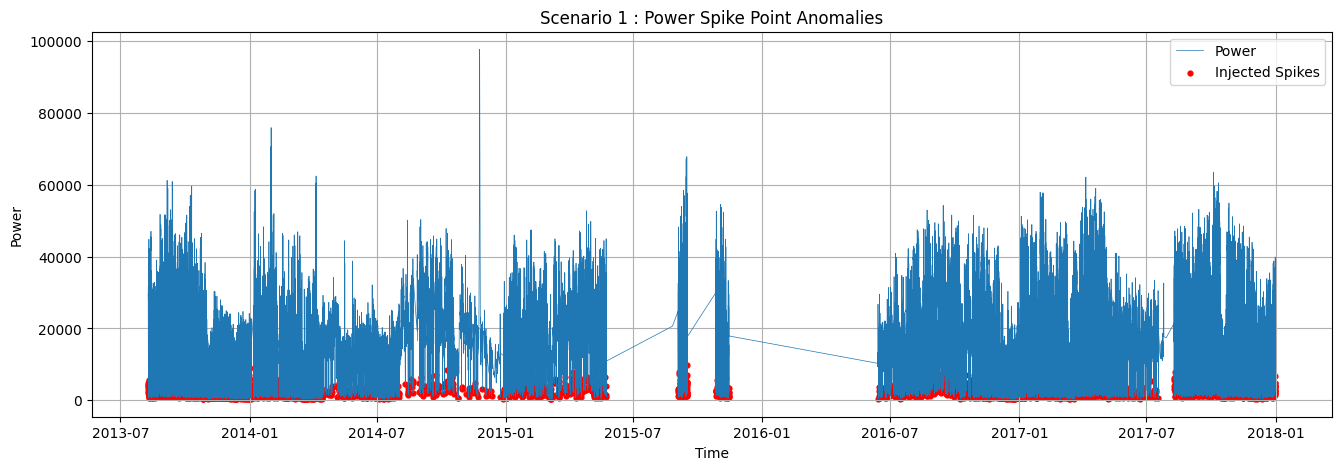


Running IForest
Detected Anomalies : 9280
Precision          : 0.4037
Recall             : 0.3996
F1 Score           : 0.4016
ROC AUC            : 0.9898
PR AUC             : 0.3735


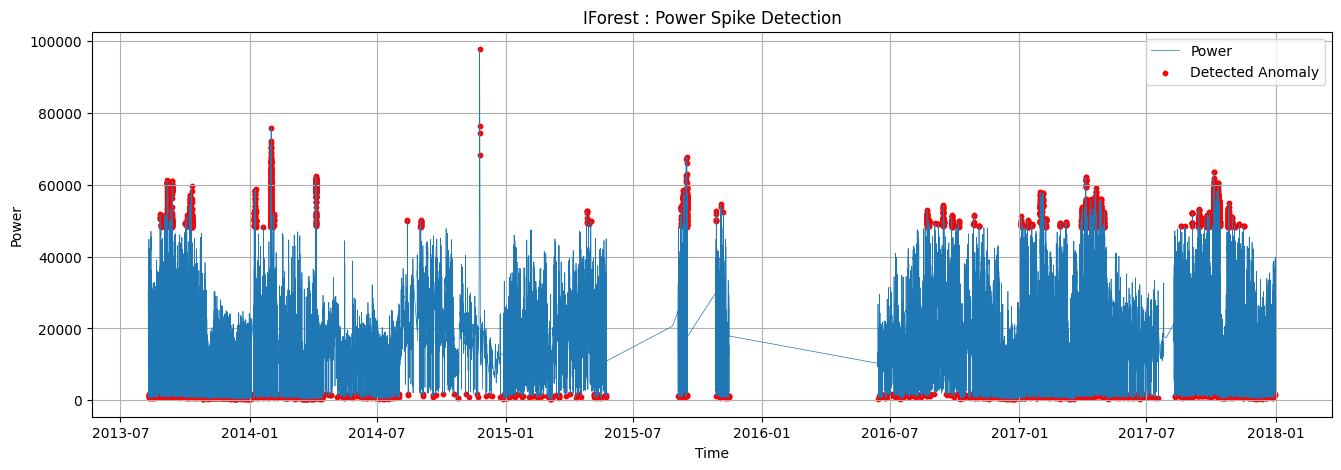


Running ECOD
Detected Anomalies : 9374
Precision          : 0.5000
Recall             : 0.5000
F1 Score           : 0.5000
ROC AUC            : 0.9935
PR AUC             : 0.4860


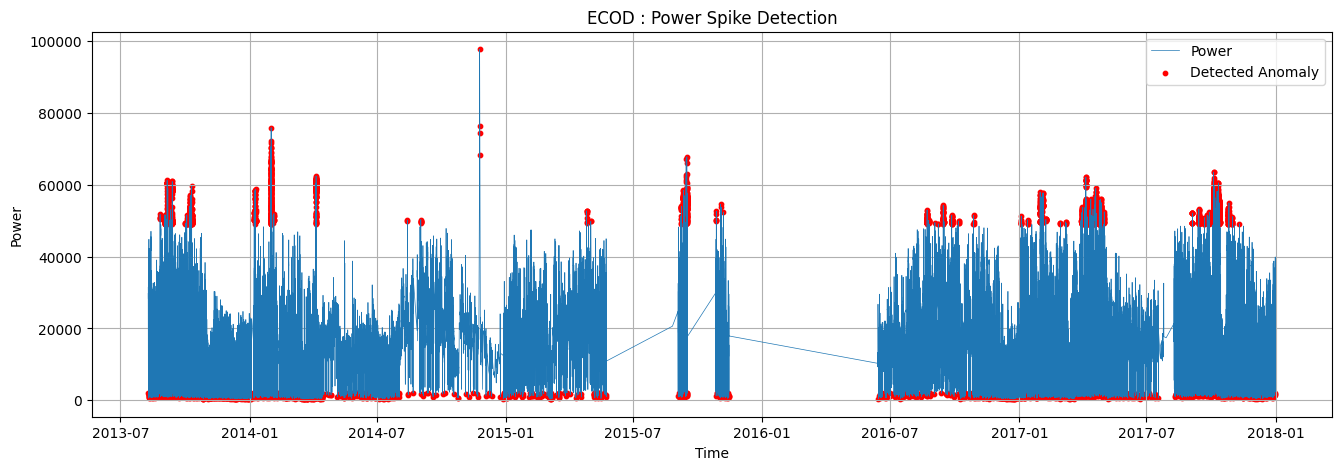


Running COPOD
Detected Anomalies : 9375
Precision          : 0.0097
Recall             : 0.0097
F1 Score           : 0.0097
ROC AUC            : 0.9296
PR AUC             : 0.0606


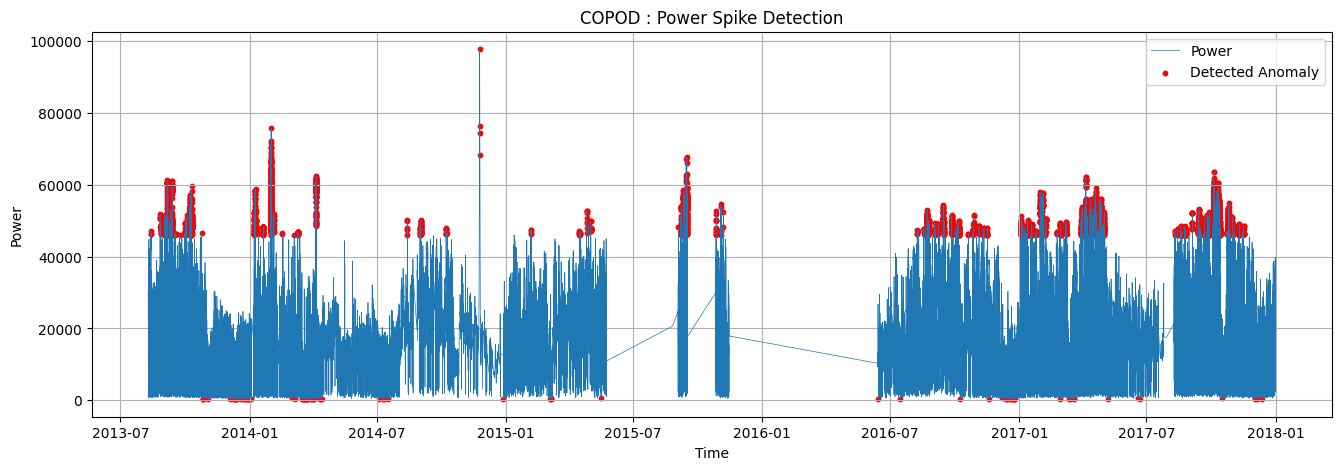


Running HBOS
Detected Anomalies : 4729
Precision          : 0.0000
Recall             : 0.0000
F1 Score           : 0.0000
ROC AUC            : 0.8104
PR AUC             : 0.0398


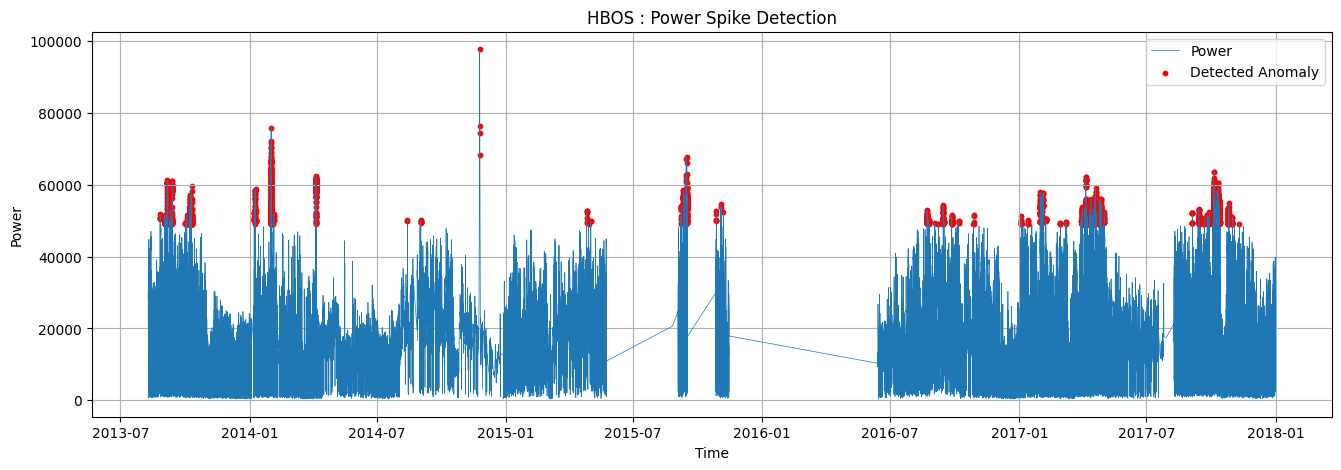


Running LOF
Detected Anomalies : 9375
Precision          : 0.0099
Recall             : 0.0099
F1 Score           : 0.0099
ROC AUC            : 0.4964
PR AUC             : 0.0099


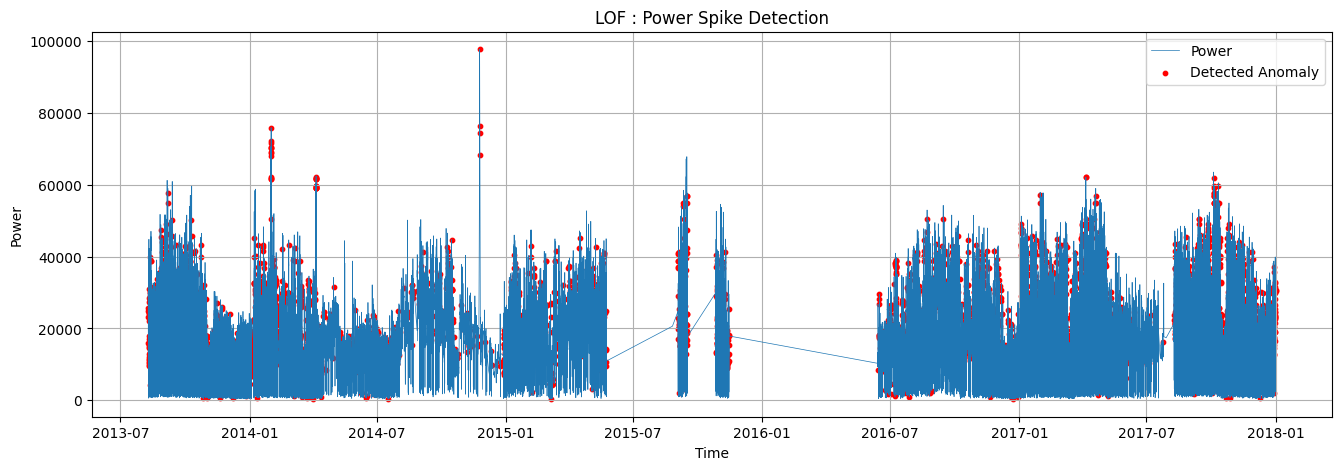


Running KNN
Detected Anomalies : 9373
Precision          : 0.1706
Recall             : 0.1706
F1 Score           : 0.1706
ROC AUC            : 0.9704
PR AUC             : 0.1782


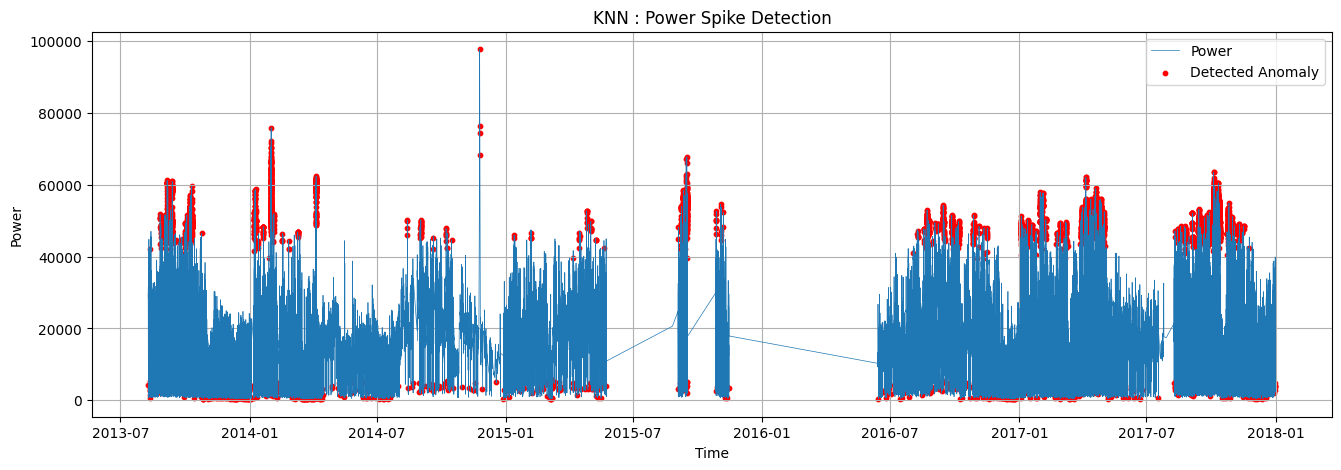


Running PCA
Detected Anomalies : 9375
Precision          : 0.7699
Recall             : 0.7700
F1 Score           : 0.7700
ROC AUC            : 0.9973
PR AUC             : 0.6591


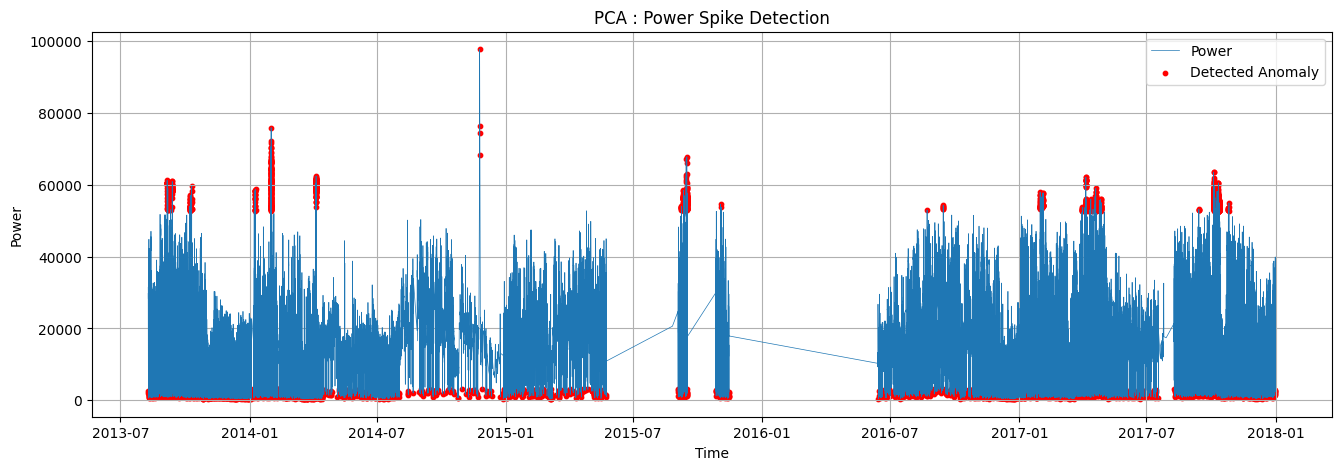


Running MCD
Detected Anomalies : 9375
Precision          : 0.0000
Recall             : 0.0000
F1 Score           : 0.0000
ROC AUC            : 0.8707
PR AUC             : 0.0352


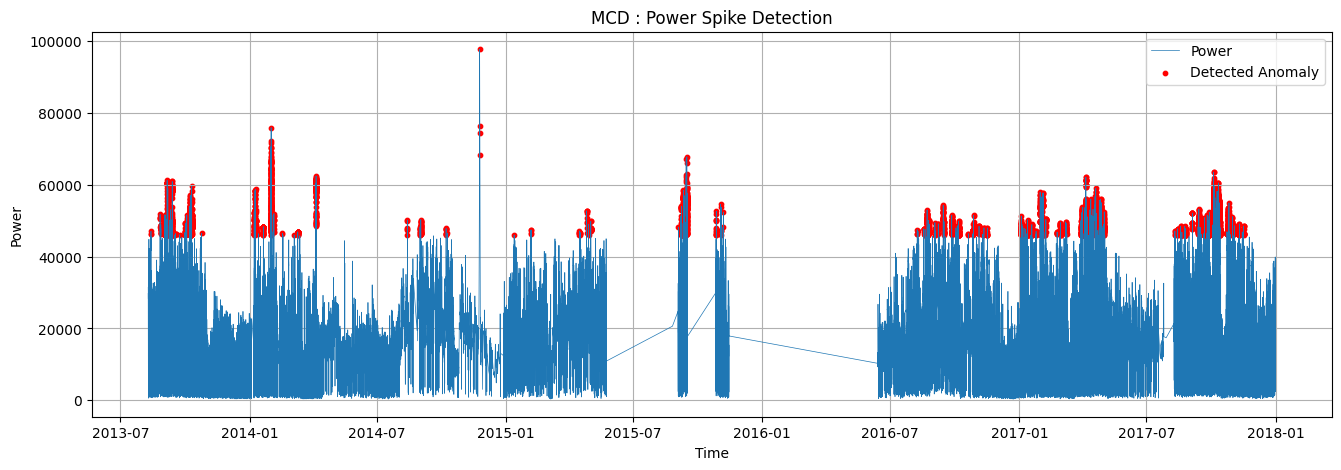


Running LODA
Detected Anomalies : 4729
Precision          : 0.0000
Recall             : 0.0000
F1 Score           : 0.0000
ROC AUC            : 0.2853
PR AUC             : 0.0130


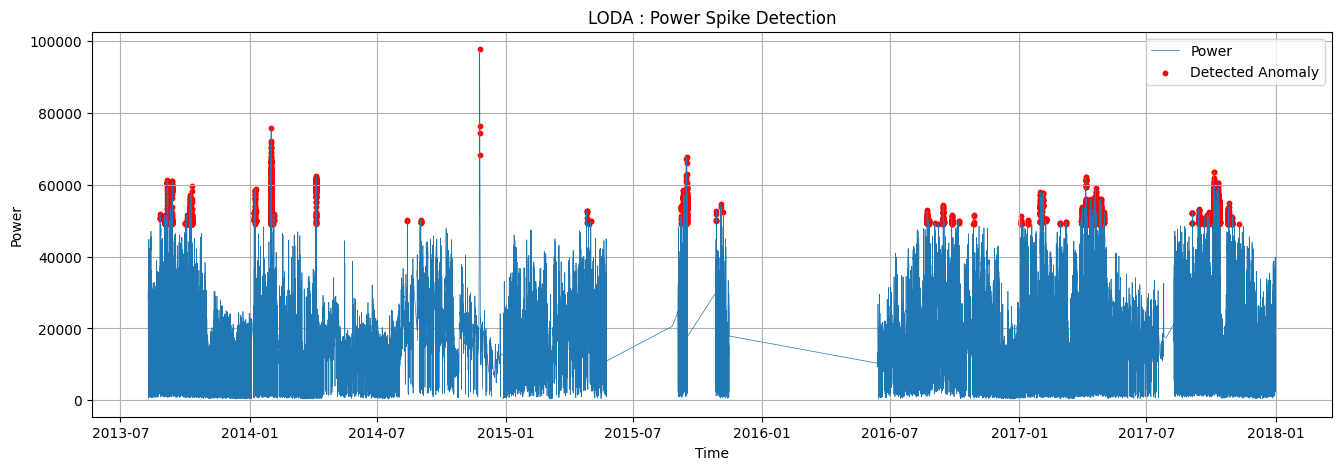


Running INNE
Detected Anomalies : 9323
Precision          : 0.4802
Recall             : 0.4776
F1 Score           : 0.4789
ROC AUC            : 0.9895
PR AUC             : 0.3888


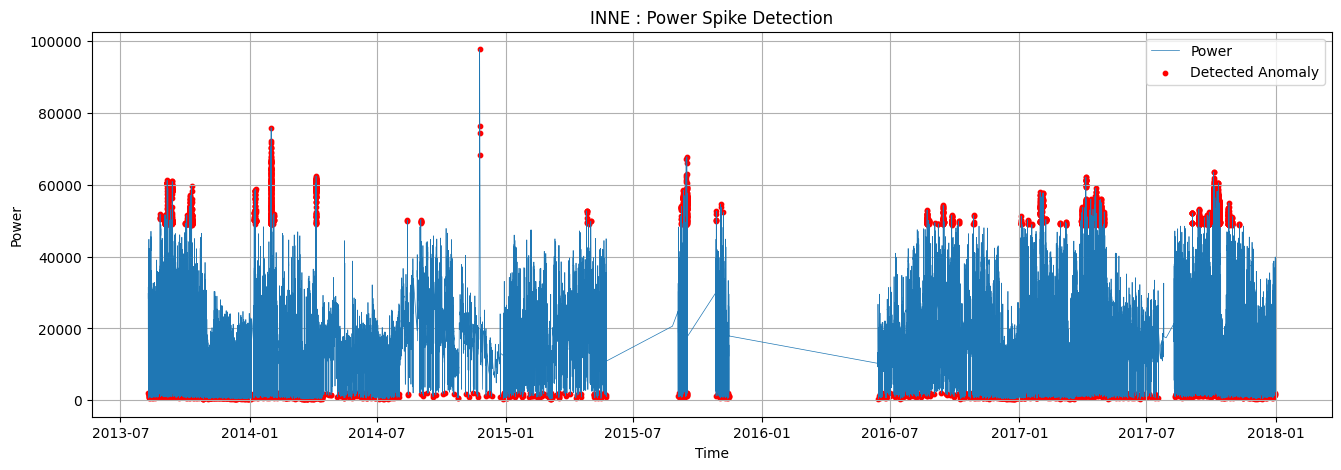



BENCHMARK SUMMARY


,Scenario,Model,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,FN,TN
6,Power Spike,PCA,0.769920,0.770002,0.769961,0.997344,0.659129,7218,2157,2156,925933
1,Power Spike,ECOD,0.500000,0.500000,0.500000,0.993484,0.485982,4687,4687,4687,923403
9,Power Spike,INNE,0.480210,0.477598,0.478900,0.989467,0.388796,4477,4846,4897,923244
0,Power Spike,IForest,0.403664,0.399616,0.401630,0.989776,0.373472,3746,5534,5628,922556
5,Power Spike,KNN,0.170596,0.170578,0.170587,0.970388,0.178178,1599,7774,7775,920316
4,Power Spike,LOF,0.009920,0.009921,0.009921,0.496391,0.009899,93,9282,9281,918808
2,Power Spike,COPOD,0.009707,0.009708,0.009707,0.929620,0.060622,91,9284,9283,918806
3,Power Spike,HBOS,0.000000,0.000000,0.000000,0.810369,0.039848,0,4729,9374,923361
7,Power Spike,MCD,0.000000,0.000000,0.000000,0.870726,0.035197,0,9375,9374,918715
8,Power Spike,LODA,0.000000,0.000000,0.000000,0.285345,0.012963,0,4729,9374,923361


In [ ]:
# ============================================
# SCENARIO 2 : POWER DROP (POINT ANOMALY)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# PyOD Models
# -------------------------------
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.pca import PCA
from pyod.models.mcd import MCD
from pyod.models.loda import LODA
from pyod.models.inne import INNE

# -------------------------------
# Evaluation Metrics
# -------------------------------
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# -------------------------------
# Load cleaned dataset
# -------------------------------
df = pd.read_csv("boys_hostel_mains_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

# ============================================
# Inject Power Drop Anomalies
# ============================================

labels = np.zeros(len(df), dtype=int)

np.random.seed(42)

# Inject anomalies into 1% of the dataset
n_anomalies = int(0.01 * len(df))

indices = np.random.choice(
    df.index,
    size=n_anomalies,
    replace=False
)

# Reduce selected power readings to 5-20% of original
drop_factor = np.random.uniform(
    low=0.05,
    high=0.20,
    size=n_anomalies
)

df.loc[indices, "power"] = (
    df.loc[indices, "power"].values
    * drop_factor
)

# Ground truth labels
labels[indices] = 1
df["label"] = labels

print(f"\nInjected {labels.sum()} power drop anomalies.")

# ============================================
# Visualize Injected Scenario
# ============================================

plt.figure(figsize=(16, 5))

plt.plot(
    df["date"],
    df["power"],
    linewidth=0.5,
    label="Power"
)

plt.scatter(
    df.loc[indices, "date"],
    df.loc[indices, "power"],
    color="red",
    s=12,
    label="Injected Power Drop"
)

plt.title("Scenario 2 : Power Drop (Point Anomaly)")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# PyOD Benchmark Models
# ============================================

models = {
    "IForest": IForest(contamination=0.01, random_state=42),
    "ECOD": ECOD(contamination=0.01),
    "COPOD": COPOD(contamination=0.01),
    "HBOS": HBOS(contamination=0.01),
    "LOF": LOF(contamination=0.01),
    "KNN": KNN(contamination=0.01),
    "PCA": PCA(contamination=0.01),
    "MCD": MCD(contamination=0.01, random_state=42),
    "LODA": LODA(contamination=0.01),
    "INNE": INNE(contamination=0.01)
}

# Input feature
X = df[["power"]].values

# Store benchmark results
results = []

# ============================================
# Run All Models
# ============================================

for name, model in models.items():

    print("\n" + "=" * 50)
    print(f"Running {name}")
    print("=" * 50)

    # Train
    model.fit(X)

    # Predictions
    predictions = model.labels_
    scores = model.decision_scores_

    # Evaluation
    y_true = df["label"].values
    y_pred = predictions
    y_score = scores

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    # Store results
    results.append({
        "Scenario": "Power Spike",
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

    # Print summary
    print(f"Detected Anomalies : {y_pred.sum()}")
    print(f"Precision          : {precision:.4f}")
    print(f"Recall             : {recall:.4f}")
    print(f"F1 Score           : {f1:.4f}")
    print(f"ROC AUC            : {roc_auc:.4f}")
    print(f"PR AUC             : {pr_auc:.4f}")

    # Visualize detections
    detected = df[y_pred == 1]

    plt.figure(figsize=(16, 5))

    plt.plot(
        df["date"],
        df["power"],
        linewidth=0.5,
        label="Power"
    )

    plt.scatter(
        detected["date"],
        detected["power"],
        color="red",
        s=10,
        label="Detected Anomaly"
    )

    plt.title(f"{name} : Power Spike Detection")
    plt.xlabel("Time")
    plt.ylabel("Power")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Save predictions into dataframe
    df[f"{name}_pred"] = y_pred
    df[f"{name}_score"] = y_score

# ============================================
# Benchmark Summary
# ============================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)

display(
    results_df.sort_values(
        by=["F1", "PR_AUC"],
        ascending=False
    )
)

# ============================================
# Save Outputs
# ============================================

# df.to_csv(
#     "boys_power_spike.csv",
#     index=False
# )

# results_df.to_csv(
#     "boys_power_spike_results.csv",
#     index=False
# )

# print("\nSaved:")
# print("  boys_power_spike.csv")
# print("  boys_power_spike_results.csv")


Injected 9374 sequential fluctuation anomalies.


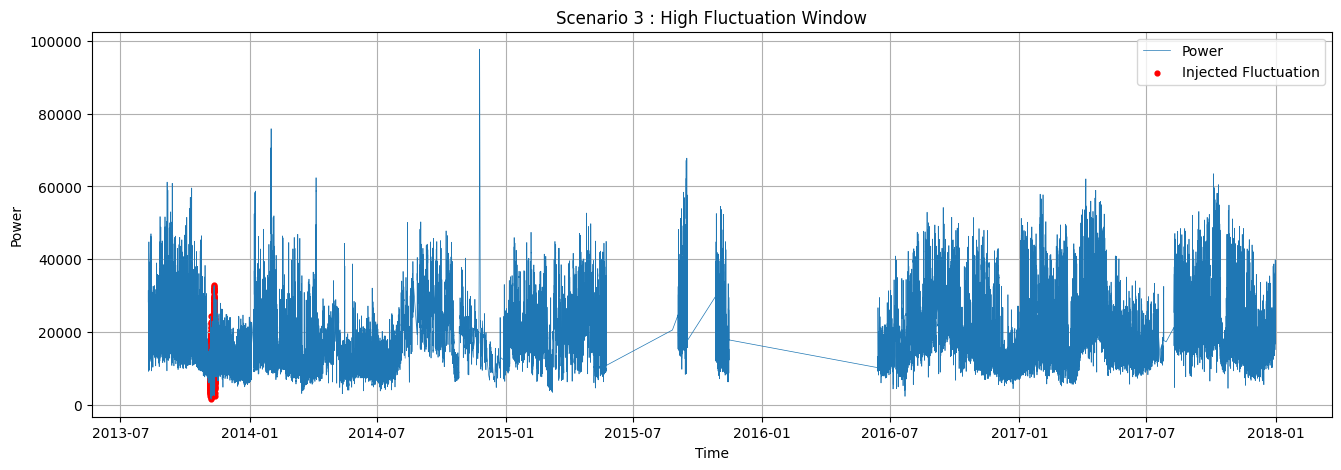


Running IForest
Detected Anomalies : 9355
Precision          : 0.0161
Recall             : 0.0161
F1 Score           : 0.0161
ROC AUC            : 0.4854
PR AUC             : 0.0097


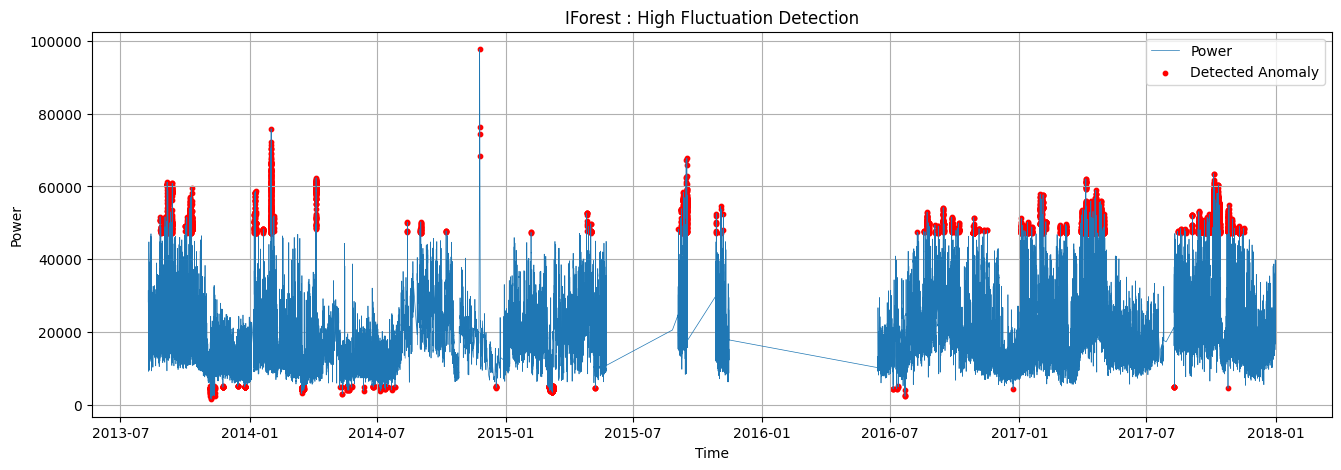


Running ECOD
Detected Anomalies : 9374
Precision          : 0.0366
Recall             : 0.0366
F1 Score           : 0.0366
ROC AUC            : 0.5753
PR AUC             : 0.0159


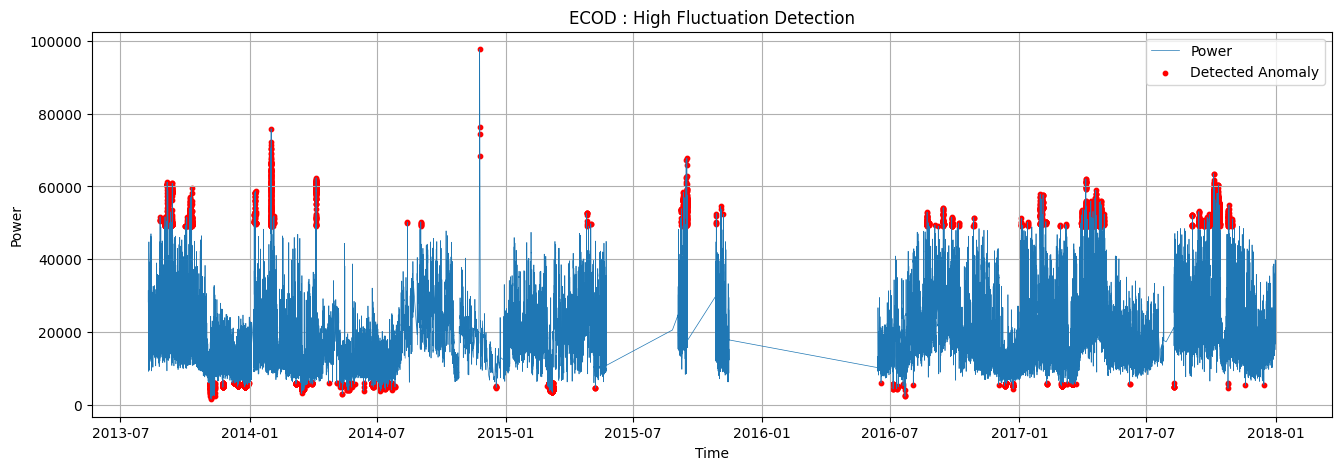


Running COPOD
Detected Anomalies : 9375
Precision          : 0.0052
Recall             : 0.0052
F1 Score           : 0.0052
ROC AUC            : 0.4481
PR AUC             : 0.0082


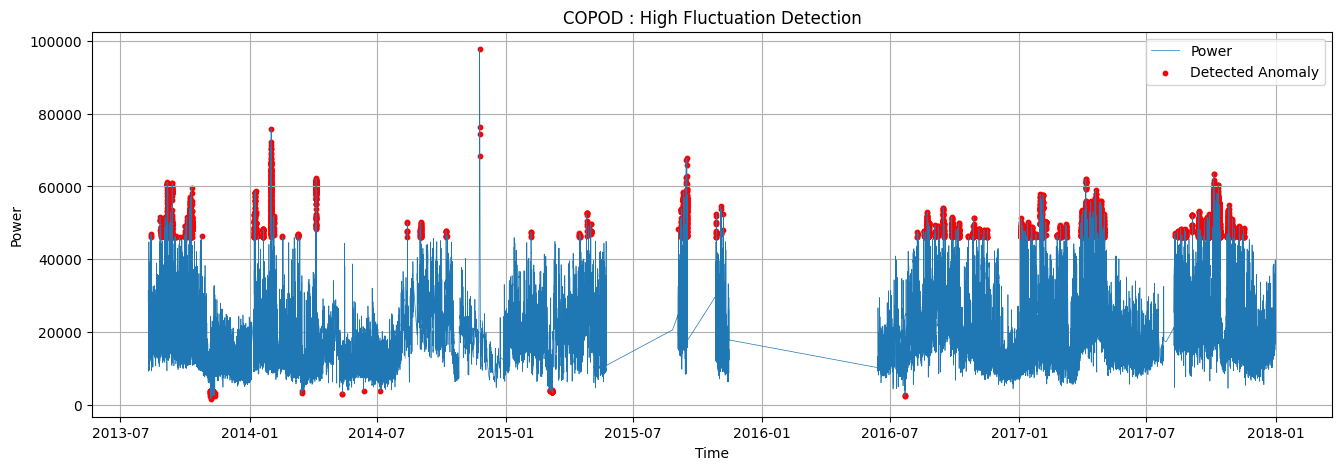


Running HBOS
Detected Anomalies : 4167
Precision          : 0.0000
Recall             : 0.0000
F1 Score           : 0.0000
ROC AUC            : 0.4950
PR AUC             : 0.0122


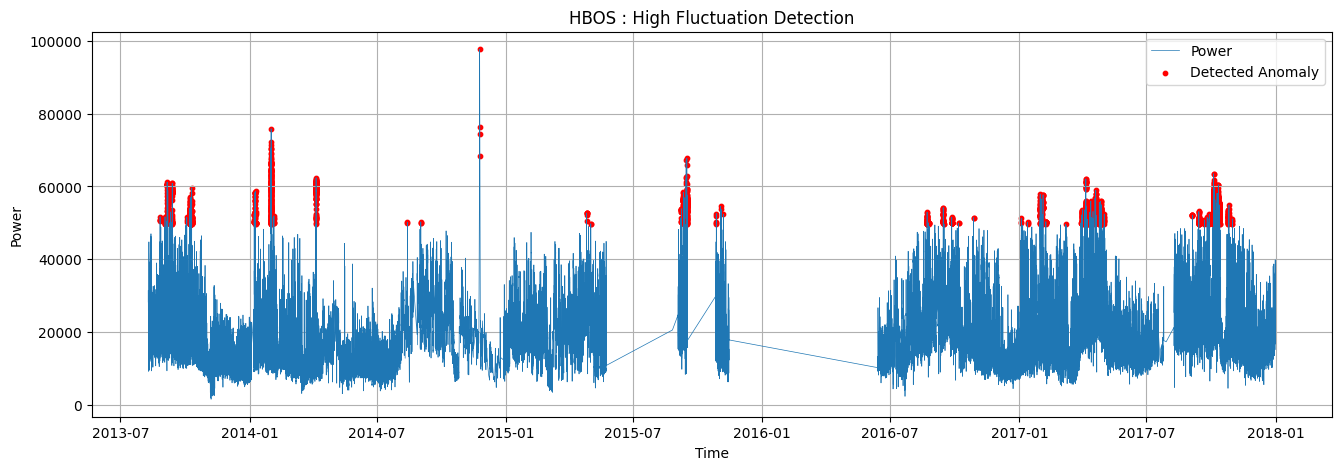


Running LOF
Detected Anomalies : 9375
Precision          : 0.0144
Recall             : 0.0144
F1 Score           : 0.0144
ROC AUC            : 0.5030
PR AUC             : 0.0106


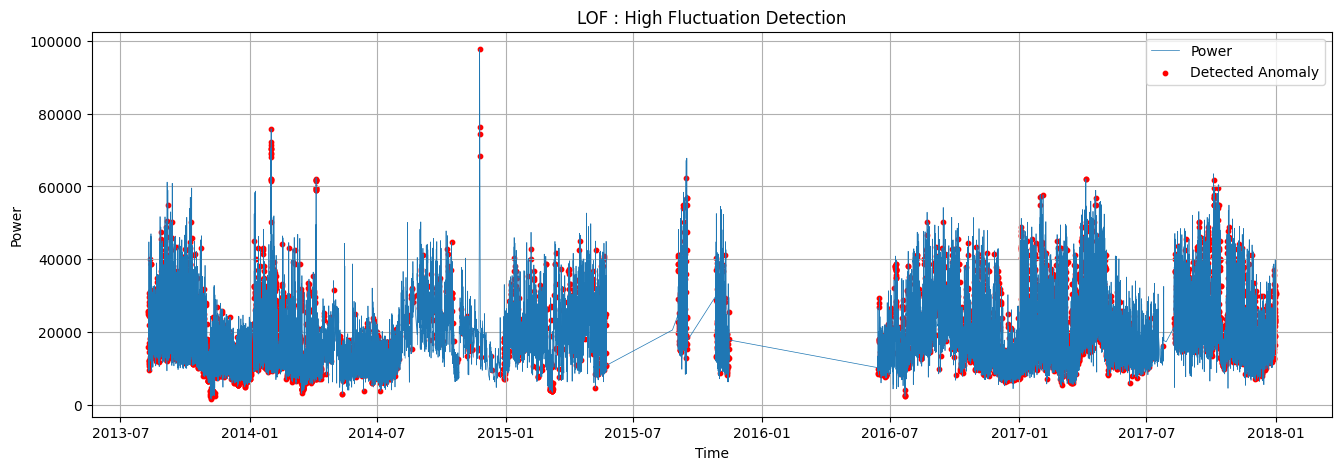


Running KNN
Detected Anomalies : 9375
Precision          : 0.0155
Recall             : 0.0155
F1 Score           : 0.0155
ROC AUC            : 0.4150
PR AUC             : 0.0086


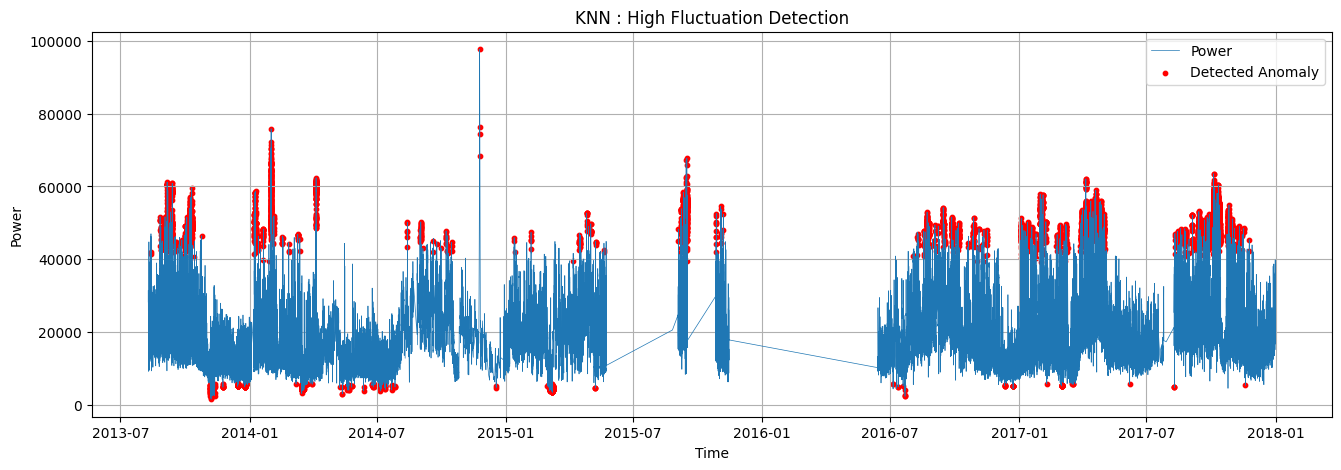


Running PCA
Detected Anomalies : 9375
Precision          : 0.0385
Recall             : 0.0385
F1 Score           : 0.0385
ROC AUC            : 0.7497
PR AUC             : 0.0230


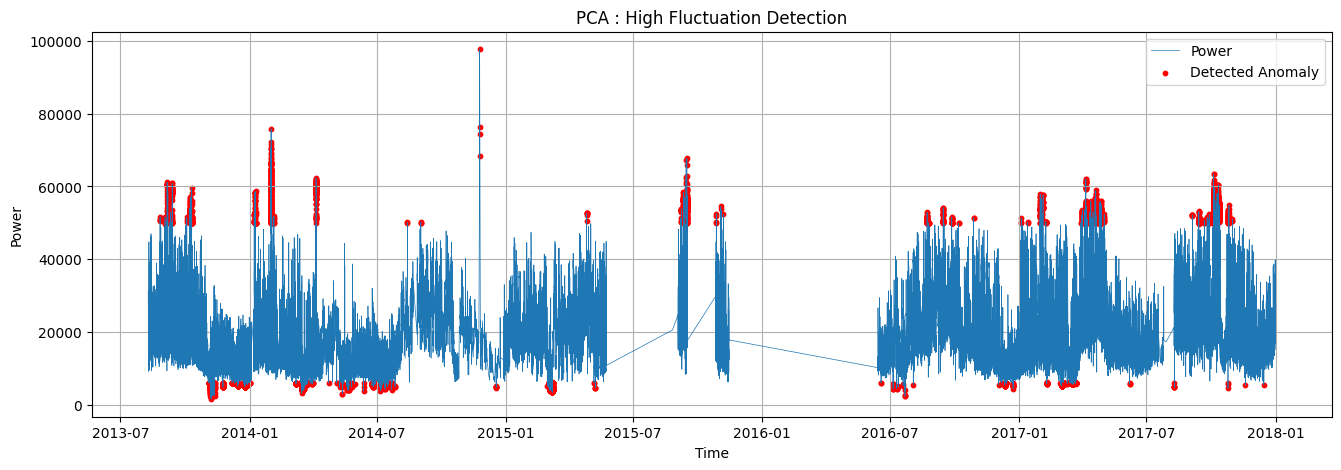


Running MCD
Detected Anomalies : 9375
Precision          : 0.0000
Recall             : 0.0000
F1 Score           : 0.0000
ROC AUC            : 0.4629
PR AUC             : 0.0084


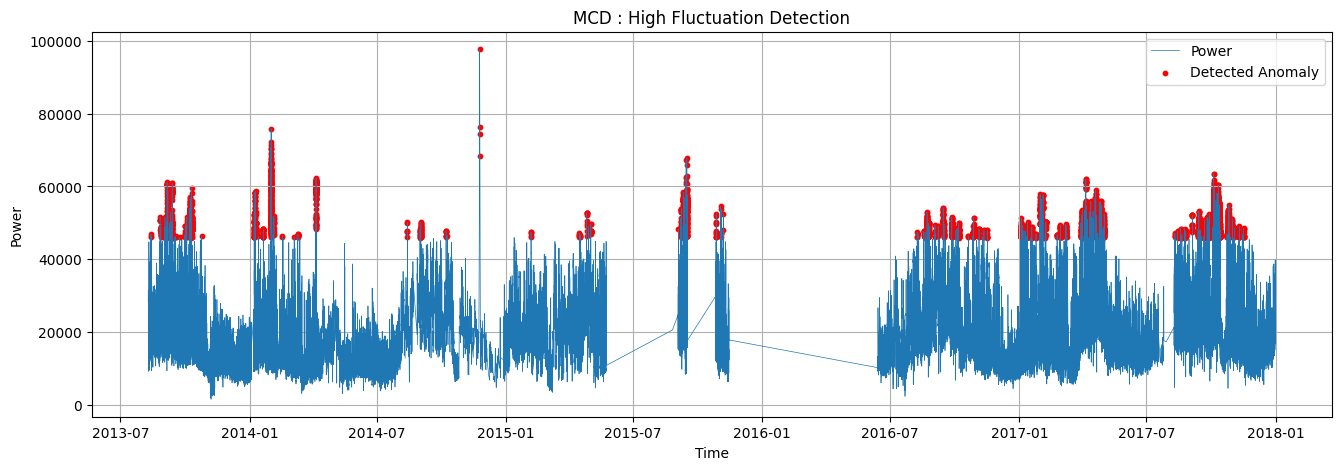


Running LODA
Detected Anomalies : 4167
Precision          : 0.0000
Recall             : 0.0000
F1 Score           : 0.0000
ROC AUC            : 0.3840
PR AUC             : 0.0092


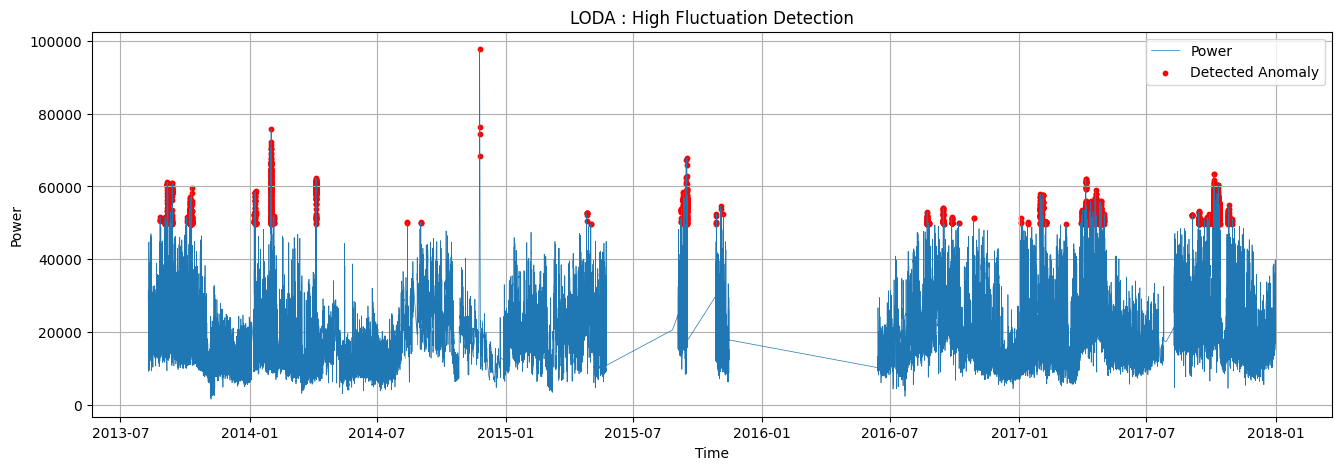


Running INNE
Detected Anomalies : 9085
Precision          : 0.0247
Recall             : 0.0239
F1 Score           : 0.0243
ROC AUC            : 0.4521
PR AUC             : 0.0095


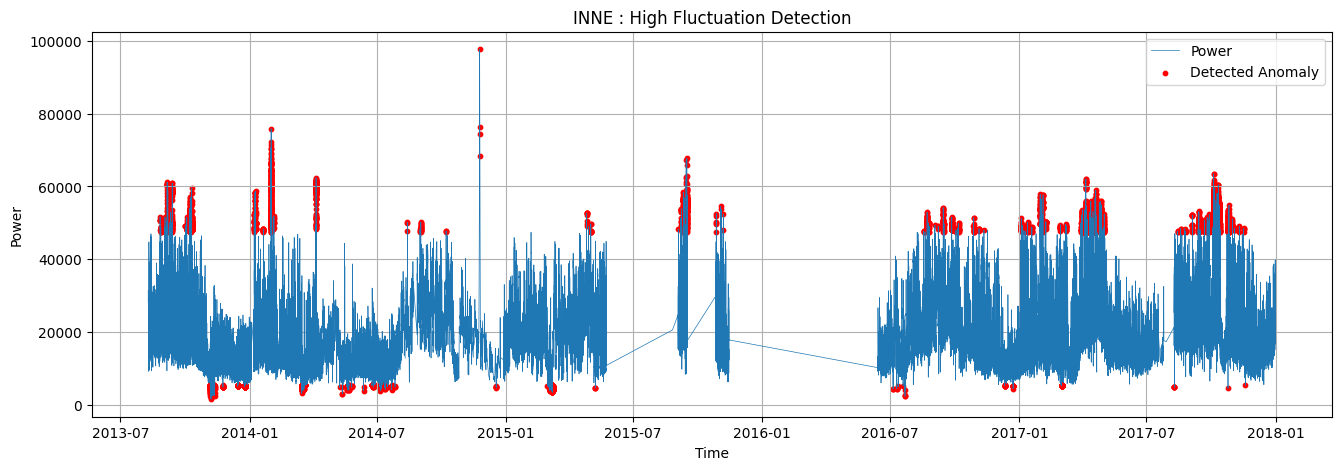



BENCHMARK SUMMARY


,Scenario,Model,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,FN,TN
6,High Fluctuation Window,PCA,0.038507,0.038511,0.038509,0.749740,0.022995,361,9014,9013,919076
1,High Fluctuation Window,ECOD,0.036591,0.036591,0.036591,0.575320,0.015911,343,9031,9031,919059
9,High Fluctuation Window,INNE,0.024656,0.023896,0.024270,0.452106,0.009512,224,8861,9150,919229
0,High Fluctuation Window,IForest,0.016141,0.016108,0.016125,0.485429,0.009671,151,9204,9223,918886
5,High Fluctuation Window,KNN,0.015467,0.015468,0.015467,0.415009,0.008602,145,9230,9229,918860
4,High Fluctuation Window,LOF,0.014400,0.014402,0.014401,0.502952,0.010615,135,9240,9239,918850
2,High Fluctuation Window,COPOD,0.005227,0.005227,0.005227,0.448086,0.008238,49,9326,9325,918764
3,High Fluctuation Window,HBOS,0.000000,0.000000,0.000000,0.495000,0.012183,0,4167,9374,923923
8,High Fluctuation Window,LODA,0.000000,0.000000,0.000000,0.383991,0.009249,0,4167,9374,923923
7,High Fluctuation Window,MCD,0.000000,0.000000,0.000000,0.462867,0.008403,0,9375,9374,918715


In [2]:
# ============================================
# SCENARIO 3 : HIGH FLUCTUATION WINDOW
# SEQUENTIAL ANOMALY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.pca import PCA
from pyod.models.mcd import MCD
from pyod.models.loda import LODA
from pyod.models.inne import INNE

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

df = pd.read_csv("boys_hostel_mains_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

labels = np.zeros(len(df), dtype=int)

np.random.seed(42)

window_size = max(500, int(0.01 * len(df)))
start = np.random.randint(0, len(df) - window_size)

noise = np.random.normal(
    loc=0,
    scale=df["power"].std() * 0.25,
    size=window_size
)

anomaly_range = np.arange(start, start + window_size)

df.loc[anomaly_range, "power"] = df.loc[anomaly_range, "power"].values + noise
labels[anomaly_range] = 1
df["label"] = labels

print(f"\nInjected {labels.sum()} sequential fluctuation anomalies.")

plt.figure(figsize=(16, 5))
plt.plot(df["date"], df["power"], linewidth=0.5, label="Power")
plt.scatter(
    df.loc[anomaly_range, "date"],
    df.loc[anomaly_range, "power"],
    color="red",
    s=12,
    label="Injected Fluctuation"
)
plt.title("Scenario 3 : High Fluctuation Window")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

models = {
    "IForest": IForest(contamination=0.01, random_state=42),
    "ECOD": ECOD(contamination=0.01),
    "COPOD": COPOD(contamination=0.01),
    "HBOS": HBOS(contamination=0.01),
    "LOF": LOF(contamination=0.01),
    "KNN": KNN(contamination=0.01),
    "PCA": PCA(contamination=0.01),
    "MCD": MCD(contamination=0.01, random_state=42),
    "LODA": LODA(contamination=0.01),
    "INNE": INNE(contamination=0.01)
}

X = df[["power"]].values
results = []

for name, model in models.items():
    print("\n" + "=" * 50)
    print(f"Running {name}")
    print("=" * 50)

    model.fit(X)

    predictions = model.labels_
    scores = model.decision_scores_

    y_true = df["label"].values
    y_pred = predictions
    y_score = np.nan_to_num(scores, nan=0.0)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)
    except ValueError:
        roc_auc = np.nan
        pr_auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results.append({
        "Scenario": "High Fluctuation Window",
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

    print(f"Detected Anomalies : {y_pred.sum()}")
    print(f"Precision          : {precision:.4f}")
    print(f"Recall             : {recall:.4f}")
    print(f"F1 Score           : {f1:.4f}")
    print(f"ROC AUC            : {roc_auc:.4f}")
    print(f"PR AUC             : {pr_auc:.4f}")

    detected = df[y_pred == 1]

    plt.figure(figsize=(16, 5))
    plt.plot(df["date"], df["power"], linewidth=0.5, label="Power")
    plt.scatter(
        detected["date"],
        detected["power"],
        color="red",
        s=10,
        label="Detected Anomaly"
    )
    plt.title(f"{name} : High Fluctuation Detection")
    plt.xlabel("Time")
    plt.ylabel("Power")
    plt.legend()
    plt.grid(True)
    plt.show()

    df[f"{name}_pred"] = y_pred
    df[f"{name}_score"] = y_score

results_df = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)

display(results_df.sort_values(by=["F1", "PR_AUC"], ascending=False))

# df.to_csv("boys_high_fluctuation.csv", index=False)
# results_df.to_csv("boys_high_fluctuation_results.csv", index=False)

# print("\nSaved:")
# print("boys_high_fluctuation.csv")
# print("boys_high_fluctuation_results.csv")

In [4]:
df.head()

,timestamp,power,current,voltage,frequency,power_factor,date,label,IForest_pred,IForest_score,...,KNN_pred,KNN_score,PCA_pred,PCA_score,MCD_pred,MCD_score,LODA_pred,LODA_score,INNE_pred,INNE_score
0,1.376073e+09,28298.05859,NaN,243.54842,50.33528,0.96101,2013-08-09 18:30:00,0,0,-0.179205,...,0,0.04859,0,0.030798,0,3.992394,0,0.015879,0,0.669964
1,1.376073e+09,28327.11426,NaN,243.72989,50.36023,0.96289,2013-08-09 18:31:00,0,0,-0.180672,...,0,0.19426,0,0.034076,0,4.011837,0,0.015879,0,0.669964
2,1.376073e+09,28343.01562,NaN,243.94641,50.41634,0.96056,2013-08-09 18:32:00,0,0,-0.181022,...,0,0.08438,0,0.035870,0,4.022499,0,0.015879,0,0.669964
3,1.376073e+09,28447.11719,NaN,244.36275,50.45324,0.96228,2013-08-09 18:33:00,0,0,-0.184543,...,0,0.20281,0,0.047612,0,4.092643,0,0.015879,0,0.672907
4,1.376073e+09,28393.62207,NaN,244.48650,50.43779,0.96166,2013-08-09 18:34:00,0,0,-0.182487,...,0,0.09793,0,0.041578,0,4.056522,0,0.015879,0,0.669964


In [6]:
df[df["label"] == 1]

,timestamp,power,current,voltage,frequency,power_factor,date,label,IForest_pred,IForest_score,...,KNN_pred,KNN_score,PCA_pred,PCA_score,MCD_pred,MCD_score,LODA_pred,LODA_score,INNE_pred,INNE_score
121958,1.383693e+09,8051.136151,NaN,242.8368,49.74319,0.79461,2013-11-05 23:08:00,1,0,-0.170112,...,0,0.130849,0,2.253072,0,1.927357,0,0.012201,0,0.754170
121959,1.383693e+09,10416.189281,NaN,242.7788,49.75735,0.79495,2013-11-05 23:09:00,1,0,-0.219542,...,0,0.059281,0,1.986292,0,0.985507,0,0.012201,0,0.607571
121960,1.383693e+09,10367.814783,NaN,242.8089,49.80745,0.79595,2013-11-05 23:10:00,1,0,-0.223312,...,0,0.054783,0,1.991748,0,1.001636,0,0.012201,0,0.602952
121961,1.383693e+09,12334.186358,NaN,242.9768,49.86634,0.79324,2013-11-05 23:11:00,1,0,-0.240747,...,0,0.046358,0,1.769940,0,0.451494,0,0.016790,0,0.569680
121962,1.383693e+09,7246.247270,NaN,242.9857,49.85859,0.79175,2013-11-05 23:12:00,1,0,-0.128032,...,0,0.110730,0,2.343864,0,2.319268,0,0.012201,0,0.802419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131327,1.384256e+09,14251.796284,NaN,241.6100,50.10816,0.89781,2013-11-12 11:36:00,1,0,-0.255970,...,0,0.026284,0,1.553632,0,0.123344,0,0.016790,0,0.523378
131328,1.384256e+09,15652.744654,NaN,241.2758,50.01722,0.89708,2013-11-12 11:37:00,1,0,-0.261094,...,0,0.015346,0,1.395604,0,0.013663,0,0.016790,0,0.527320
131329,1.384256e+09,13848.668253,NaN,241.0522,49.95853,0.89290,2013-11-12 11:38:00,1,0,-0.250537,...,0,0.040813,0,1.599105,0,0.175250,0,0.016790,0,0.506338
131330,1.384256e+09,12498.083237,NaN,240.7808,49.88984,0.89604,2013-11-12 11:39:00,1,0,-0.245694,...,0,0.013237,0,1.751452,0,0.415407,0,0.016790,0,0.563321


In [11]:
# !pip install tensorflow
!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
    --------------------------------------- 1.8/123.0 MB 9.1 MB/s eta 0:00:14
   - -------------------------------------- 4.2/123.0 MB 10.1 MB/s eta 0:00:12
   -- ------------------------------------- 6.8/123.0 MB 11.0 MB/s eta 0:00:11
   --- ------------------------------------ 9.7/123.0 MB 11.8 MB/s eta 0:00:10
   ---- ----------------------------------- 13.1/123.0 MB 12.7 MB/s eta 0:00:09
   ----- ---------------------------------- 16.0/123.0 MB 12.9 MB/s eta 0:00:09
   ------ --------------------------------- 19.7/123.0 MB 13.4 MB/s eta 0:00:08
   ------- -------------------------------- 2


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
!pip install tqdm torch torchvision torchaudio

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -------------------- ------------------- 2.1/4.0 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 10.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
from pyod.models.iforest import IForest
from pyod.models.pca import PCA
from pyod.models.auto_encoder import AutoEncoder
from pyod.models.vae import VAE
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("boys_hostel_mains_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

# ── INJECT SEQUENTIAL ANOMALY (S3: High Fluctuation) ─────────────────────────
np.random.seed(42)
window_len = 1000
start      = np.random.randint(0, len(df) - window_len)
anom_idx   = np.arange(start, start + window_len)

raw_labels            = np.zeros(len(df), dtype=int)
raw_labels[anom_idx]  = 1

df.loc[anom_idx, "power"] += np.random.normal(0, df["power"].std() * 0.25, window_len)
df["label"] = raw_labels

# ── SLIDING WINDOWS ───────────────────────────────────────────────────────────
WINDOW_SIZE = 60          # 60 minutes of minutely data — more context than 10

power      = df["power"].values.astype(np.float32)
raw_labels = df["label"].values.astype(int)

X, y_true = [], []
for i in range(WINDOW_SIZE, len(df)):
    X.append(power[i - WINDOW_SIZE : i])
    # window is anomalous if ANY point inside it is anomalous
    y_true.append(1 if raw_labels[i - WINDOW_SIZE : i].sum() > 0 else 0)

X      = np.array(X, dtype=np.float32)
y_true = np.array(y_true)

# ── CONTAMINATION (from actual label ratio, not hardcoded) ───────────────────
contamination = float(y_true.sum() / len(y_true))
contamination = round(max(contamination, 0.001), 6)   # PyOD floor is 0.001

print(f"Anomaly windows : {y_true.sum()} / {len(y_true)}")
print(f"Contamination   : {contamination:.6f}")
print(f"Feature matrix  : {X.shape}\n")

# ── MODELS ────────────────────────────────────────────────────────────────────
models = {
    "IForest":     IForest(contamination=contamination, random_state=42, n_jobs=-1),
    "PCA":         PCA(contamination=contamination),
    "AutoEncoder": AutoEncoder(contamination=contamination, epoch_num=20, batch_size=256),
    "VAE":         VAE(contamination=contamination, epoch_num=20, batch_size=256),
}

# ── BENCHMARK ─────────────────────────────────────────────────────────────────
results = []

for name, model in models.items():
    print(f"{'='*60}\nRunning {name}\n{'='*60}")
    try:
        model.fit(X)

        y_pred  = model.labels_
        y_score = np.nan_to_num(model.decision_scores_, nan=0.0, posinf=0.0, neginf=0.0)

        results.append({
            "Model"    : name,
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall"   : recall_score(y_true, y_pred, zero_division=0),
            "F1"       : f1_score(y_true, y_pred, zero_division=0),
            "ROC_AUC"  : roc_auc_score(y_true, y_score),
            "PR_AUC"   : average_precision_score(y_true, y_score),
        })

        for k, v in results[-1].items():
            if k != "Model":
                print(f"{k:<12}: {v:.4f}")

    except Exception as e:
        print(f"{name} failed: {e}")

# ── RESULTS ───────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values(["F1", "PR_AUC"], ascending=False)
print(f"\n{'='*70}\nSEQUENTIAL ANOMALY BENCHMARK — S3 High Fluctuation\n{'='*70}")
display(results_df)

# results_df.to_csv("sequential_benchmark_s3.csv", index=False)

Anomaly windows : 1059 / 937404
Contamination   : 0.001130
Feature matrix  : (937404, 60)

Running IForest
Precision   : 0.0000
Recall      : 0.0000
F1          : 0.0000
ROC_AUC     : 0.7698
PR_AUC      : 0.0025
Running PCA
Precision   : 0.0000
Recall      : 0.0000
F1          : 0.0000
ROC_AUC     : 0.6969
PR_AUC      : 0.0018
Running AutoEncoder


Training: 100%|██████████| 20/20 [06:51<00:00, 20.57s/it]


Precision   : 0.0000
Recall      : 0.0000
F1          : 0.0000
ROC_AUC     : 0.8231
PR_AUC      : 0.0031
Running VAE


Training: 100%|██████████| 20/20 [14:31<00:00, 43.58s/it]


Precision   : 0.0000
Recall      : 0.0000
F1          : 0.0000
ROC_AUC     : 0.7546
PR_AUC      : 0.0022

SEQUENTIAL ANOMALY BENCHMARK — S3 High Fluctuation


,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
2,AutoEncoder,0.0,0.0,0.0,0.823133,0.003139
0,IForest,0.0,0.0,0.0,0.769811,0.002458
3,VAE,0.0,0.0,0.0,0.754554,0.002207
1,PCA,0.0,0.0,0.0,0.696936,0.001779


In [ ]:
import pandas as pd
import numpy as np

from pyod.models.iforest import IForest
from pyod.models.pca import PCA
from pyod.models.auto_encoder import AutoEncoder
from pyod.models.vae import VAE

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    auc
)

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("boys_hostel_mains_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

# ── INJECT S4: PERSISTENT LOAD ────────────────────────────────────────────────
# A constant additive shift over a long window
# Simulates a device stuck on / load never switching off
# Shift = 1.5 * std — large enough to be a real persistent load
# Window = 2000 mins (~33 hours) — long enough to be "persistent"

np.random.seed(42)

window_len     = 2000
shift_magnitude = df["power"].std() * 1.5

start    = np.random.randint(0, len(df) - window_len)
anom_idx = np.arange(start, start + window_len)

raw_labels           = np.zeros(len(df), dtype=int)
raw_labels[anom_idx] = 1

df.loc[anom_idx, "power"] += shift_magnitude          # flat constant shift
df["label"] = raw_labels

print(f"Shift applied   : +{shift_magnitude:.2f} W")
print(f"Anomaly window  : index {start} → {start + window_len}")

# ── SLIDING WINDOWS ───────────────────────────────────────────────────────────
WINDOW_SIZE = 60          # 60-minute context window

power      = df["power"].values.astype(np.float32)
raw_labels = df["label"].values.astype(int)

X, y_true = [], []
for i in range(WINDOW_SIZE, len(df)):
    X.append(power[i - WINDOW_SIZE : i])
    y_true.append(1 if raw_labels[i - WINDOW_SIZE : i].sum() > 0 else 0)

X      = np.array(X, dtype=np.float32)
y_true = np.array(y_true)

# ── CONTAMINATION ─────────────────────────────────────────────────────────────
contamination = float(y_true.sum() / len(y_true))
contamination = round(max(contamination, 0.001), 6)

print(f"\nAnomaly windows : {y_true.sum()} / {len(y_true)}")
print(f"Contamination   : {contamination:.6f}")
print(f"Feature matrix  : {X.shape}\n")

# ── MODELS ────────────────────────────────────────────────────────────────────
models = {
    "IForest"     : IForest(contamination=contamination, random_state=42, n_jobs=-1),
    "PCA"         : PCA(contamination=contamination),
    "AutoEncoder" : AutoEncoder(contamination=contamination, epoch_num=20, batch_size=256),
    "VAE"         : VAE(contamination=contamination, epoch_num=20, batch_size=256),
}

# ── BENCHMARK ─────────────────────────────────────────────────────────────────
results = []

for name, model in models.items():
    print(f"{'='*60}\nRunning {name}\n{'='*60}")
    try:
        model.fit(X)

        y_score = np.nan_to_num(
            model.decision_scores_,
            nan=0.0, posinf=0.0, neginf=0.0
        )

        # threshold-free metrics only
        roc_auc = roc_auc_score(y_true, y_score)
        pr_auc  = average_precision_score(y_true, y_score)

        # best achievable F1 across all thresholds
        p_curve, r_curve, thresholds = precision_recall_curve(y_true, y_score)
        f1_curve  = 2 * (p_curve * r_curve) / (p_curve + r_curve + 1e-8)
        best_f1   = float(np.max(f1_curve))
        best_thresh = float(thresholds[np.argmax(f1_curve)])

        results.append({
            "Model"      : name,
            "ROC_AUC"    : round(roc_auc, 4),
            "PR_AUC"     : round(pr_auc, 4),
            "Best_F1"    : round(best_f1, 4),
            "Threshold"  : round(best_thresh, 4),
        })

        print(f"ROC_AUC   : {roc_auc:.4f}")
        print(f"PR_AUC    : {pr_auc:.4f}")
        print(f"Best F1   : {best_f1:.4f}  (threshold {best_thresh:.4f})")

    except Exception as e:
        print(f"{name} failed: {e}")

# ── RESULTS ───────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)

print(f"\n{'='*70}")
print("SEQUENTIAL ANOMALY BENCHMARK — S4 Persistent Load")
print(f"{'='*70}")
display(results_df)

# results_df.to_csv("sequential_benchmark_s4.csv", index=False)